This page is dedicated to reproduce plots

**Package imports and basic info setup**

In [1]:
import numpy as np
from google.colab import drive
from matplotlib.lines import Line2D
from copy import deepcopy
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import pandas as pd

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
max_warmup = 1000
warmup_window = 100

window_array = np.append(np.repeat(10, 10),
                      np.repeat(warmup_window, max_warmup // warmup_window - 1))

warmup_length = np.repeat(10, len(window_array))
for i in range(len(warmup_length) - 1):
    warmup_length[i + 1] = warmup_length[i] + window_array[i + 1]

# Transition kernel for short regime
repitition = 10
num_chains_short = 2048
num_super_chains = 16

In [25]:
# quantiles for chi squared with df = 1
chi_up = 3.841459 # 95th quantile for chi squared with df = 1
chi_lo = 0.00393214  # 05th quantile for chi squared with df = 1
tau = 1e-4
num_chains_short = 2048
num_super_chains = 16
M = num_chains_short // num_super_chains
nRhat_lower = np.sqrt(1 + 1 / M + tau)
eps_lower = nRhat_lower - 1
bound = [chi_lo / num_chains_short, chi_up / num_chains_short]
threshold = eps_lower

In [8]:
utility_link = '/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/utility.py'
with open(utility_link) as f: exec(f.read())

In [23]:
def MSE_vs_Rhat(
    df,
    title,
    naive,
    bound,
    threshold,
    num_subchains,
    ColorDimension=False,
):

    fig, ax = plt.subplots(figsize=(10, 8), dpi=150)

    if ColorDimension:
        ###################################################
        # Color by Dimension (continuous)
        ###################################################

        sc = ax.scatter(
            df["Rhat"]-1,
            df["MSE"],
            c=df["Dimension"],
            cmap="viridis",      # or "turbo"
            s=35,
            alpha=0.4,
        )

        cbar = fig.colorbar(sc, ax=ax)
        cbar.set_label("Dimension")

    else:
        ###################################################
        # Color by Warmup Length (discrete)
        ###################################################

        cmap = plt.get_cmap("turbo")

        warmups = np.sort(df["Warmup Length"].unique())

        color_map = {
            w: cmap(x)
            for w, x in zip(
                warmups,
                np.linspace(0, 1, len(warmups))
            )
        }

        groups = df.groupby("Warmup Length")

        for warmup, subset in groups:
            ax.scatter(
                subset["Rhat"]-1,
                subset["MSE"],
                color=color_map[warmup],
                s=35,
                alpha=0.4,
            )

        handles = [
            Line2D(
                [0], [0],
                marker="o",
                color=color,
                linestyle="",
                markersize=8,
                label=str(warmup),
            )
            for warmup, color in color_map.items()
        ]

        ax.legend(
            handles=handles,
            title="Warmup Length",
            loc="lower right",
            ncol=2,          # helpful if you have many warmups
            fontsize=9,
        )

    ###################################################
    # Common formatting
    ###################################################

    ax.set_yscale("log")

    if not naive:
        ax.set_xscale("log")

    ax.axhline(bound[0], color="black", linestyle="--")
    ax.axhline(bound[1], color="black", linestyle="--")
    ax.axhline(1 / num_subchains, color="black")
    ax.axvline(threshold, color="blue", linestyle="--")

    ax.set_xlabel(r"$\widehat{R}_{\nu}-1$")
    ax.set_ylabel("MSE")

    suffix = "Constrained" if not naive else "Naive"
    ax.set_title(f"{title} - {suffix}")

    plt.tight_layout()
    plt.show()

# Section for Numerical Experiments

**Rosenbrock Plots**

### Load files

In [16]:
MSE_constrained_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/Rosen_MSE_constrained.pkl"
MSE_c_df = pd.read_pickle(MSE_constrained_path)
MSE_naive_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/Rosen_MSE_naive.pkl"
MSE_n_df = pd.read_pickle(MSE_naive_path)

R_hat_constrained_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/Rosen_R_Hat_constrained.pkl"
R_Hat_c_df = pd.read_pickle(R_hat_constrained_path)
R_hat_naive_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/Rosen_R_Hat_naive.pkl"
R_Hat_n_df = pd.read_pickle(R_hat_naive_path)

### Plotting - MSE vs. Warmup length

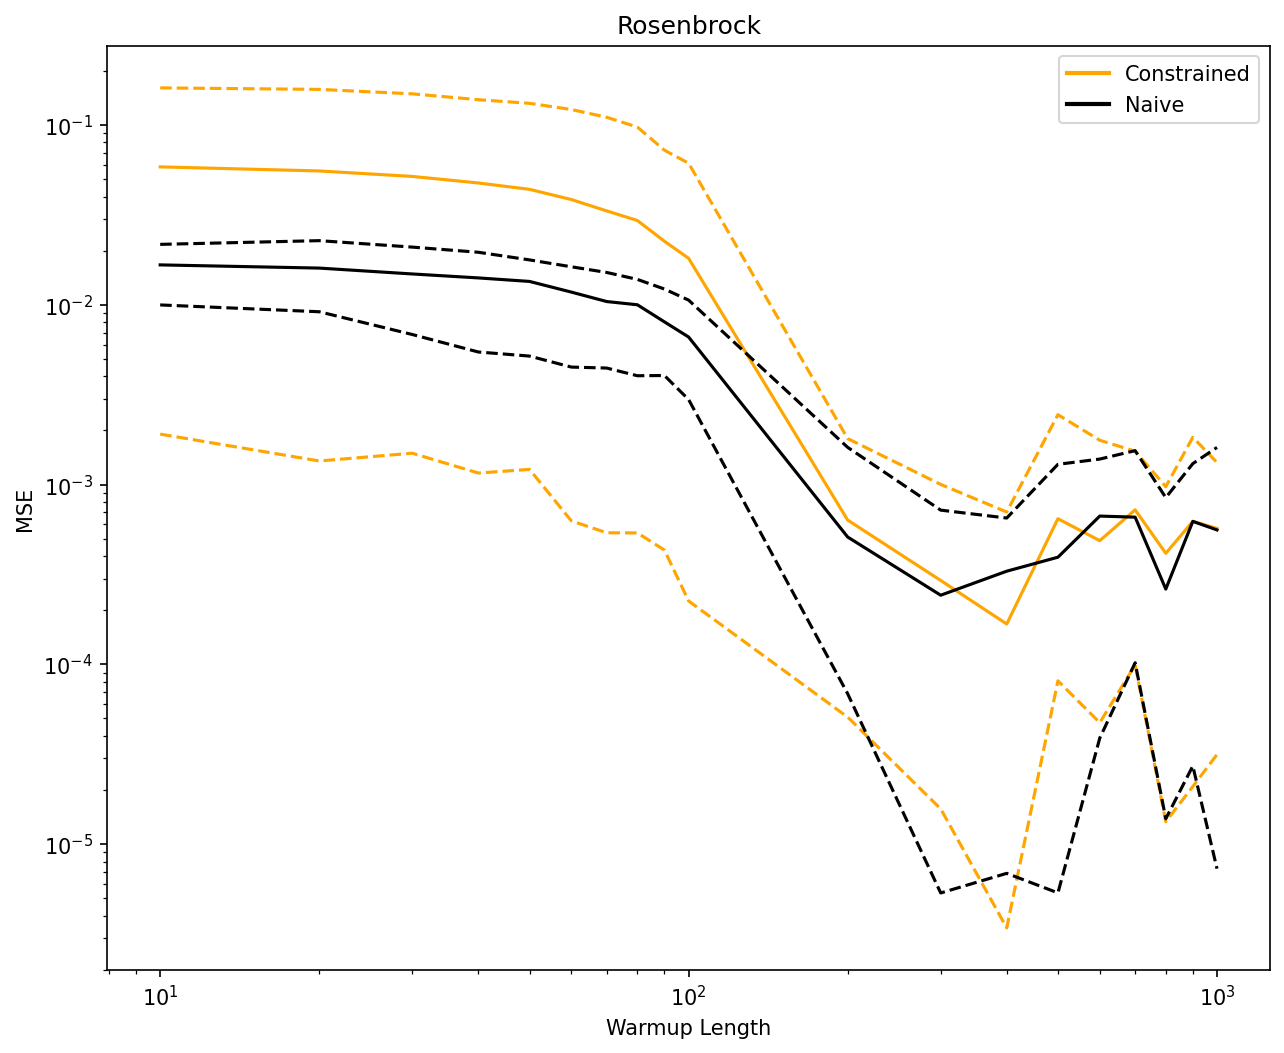

In [14]:
MSE_vs_Warmup(MSE_c_df, MSE_n_df,"Rosenbrock")

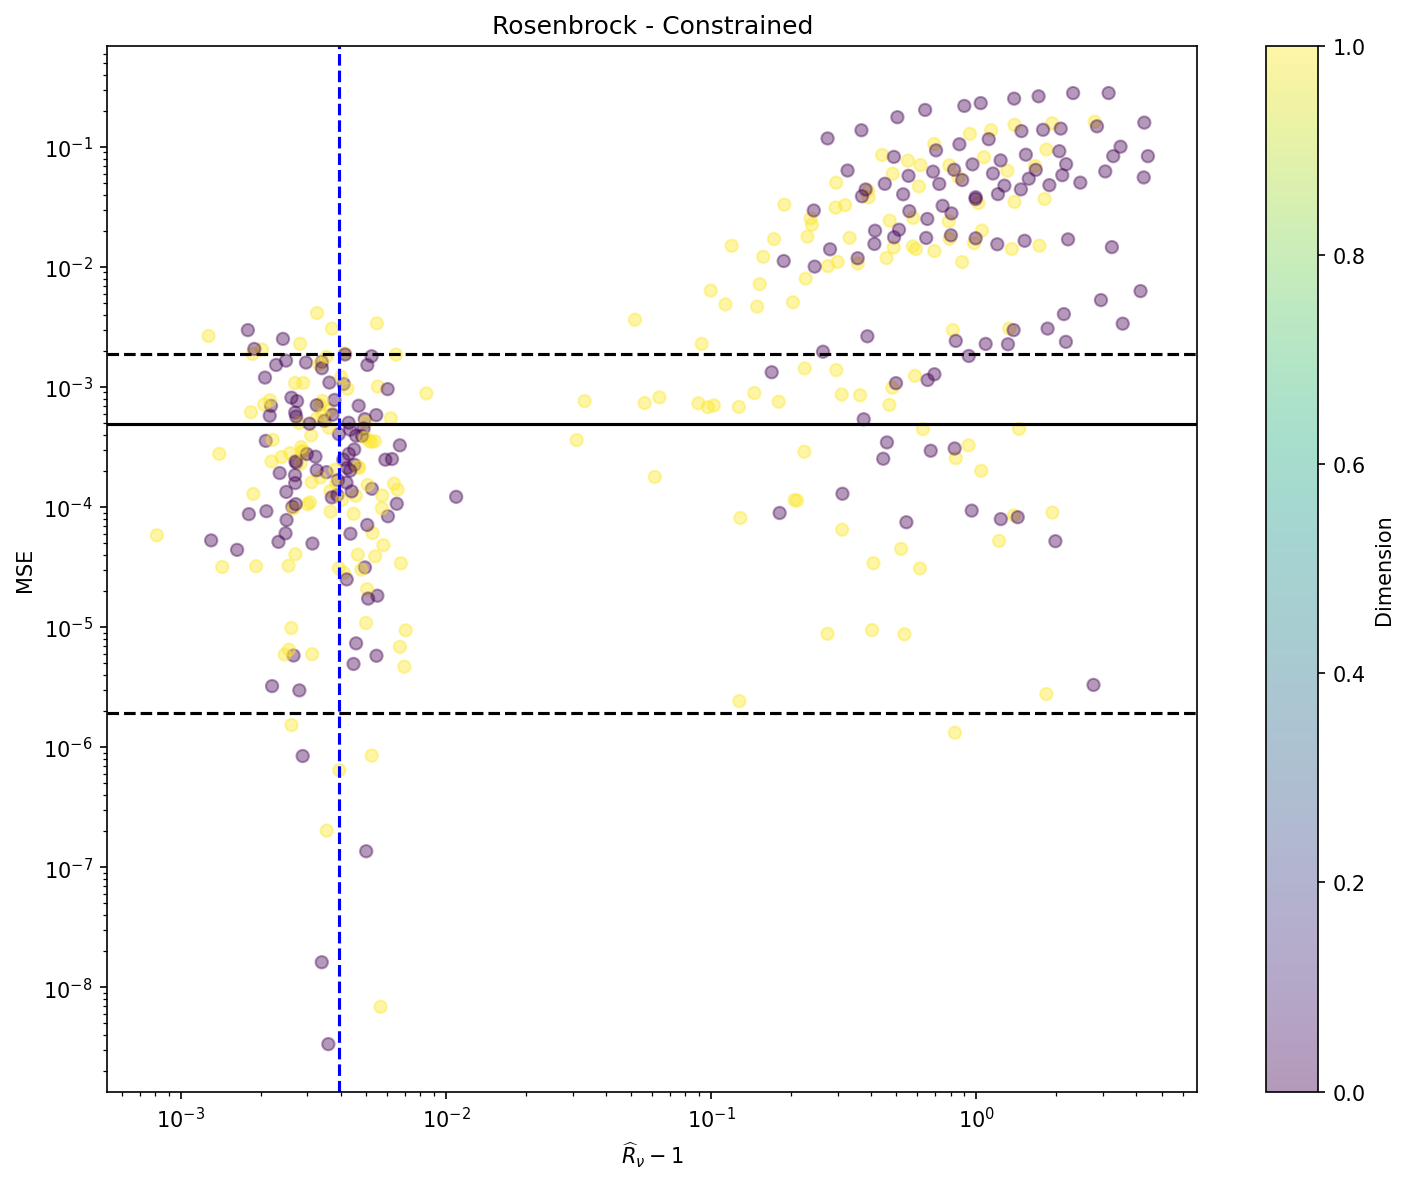

In [26]:
MSE_vs_Rhat(R_Hat_c_df,
           "Rosenbrock",
           False,
            bound, threshold,num_chains_short,True)

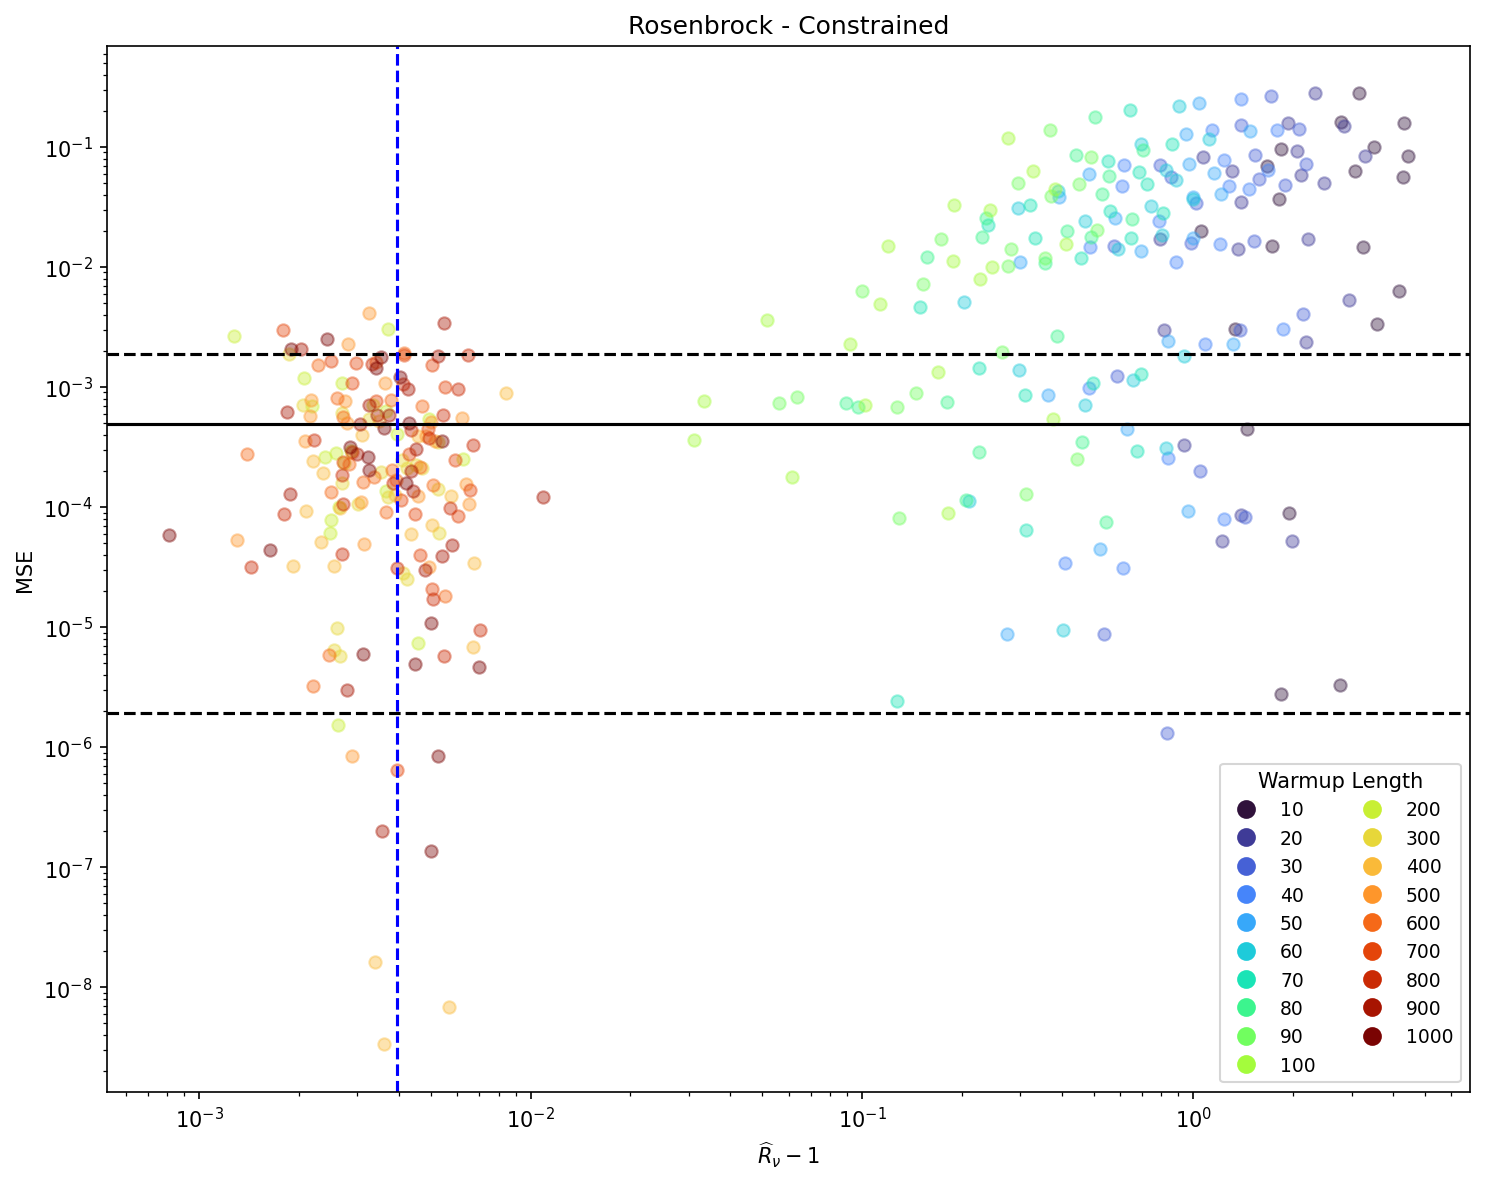

In [27]:
MSE_vs_Rhat(R_Hat_c_df,
           "Rosenbrock",
           False,
            bound, threshold,num_chains_short,False)

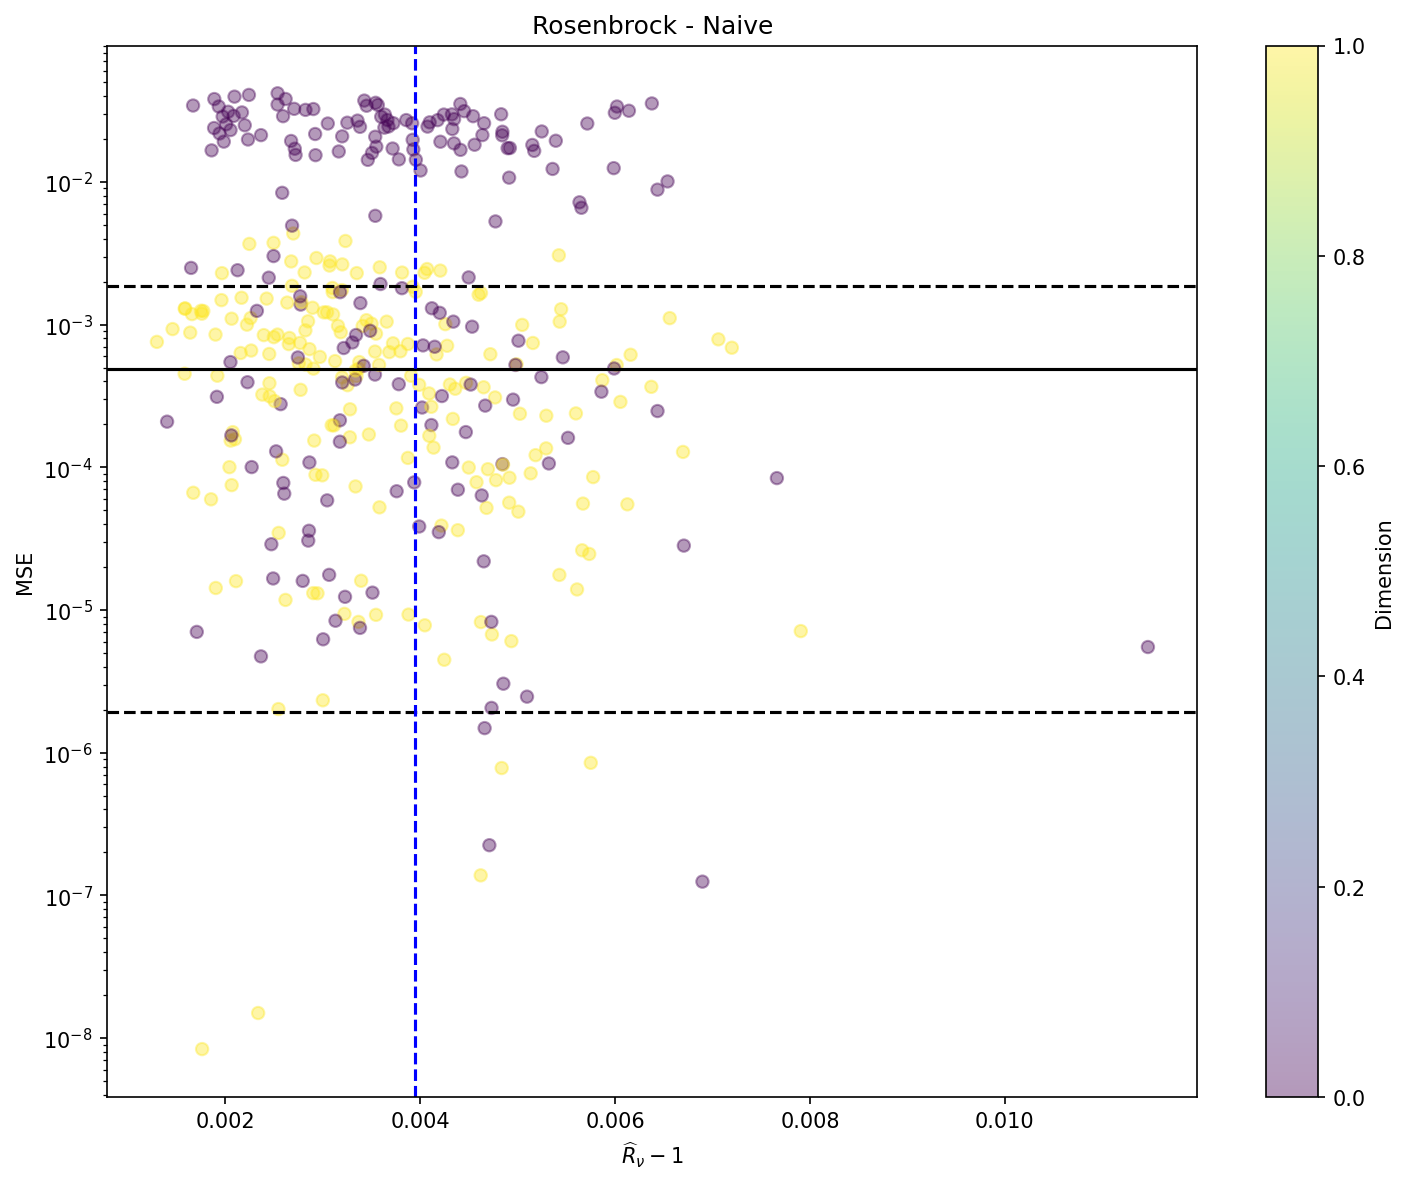

In [28]:
MSE_vs_Rhat(R_Hat_n_df,
           "Rosenbrock",
           True,
            bound, threshold,num_chains_short,True)

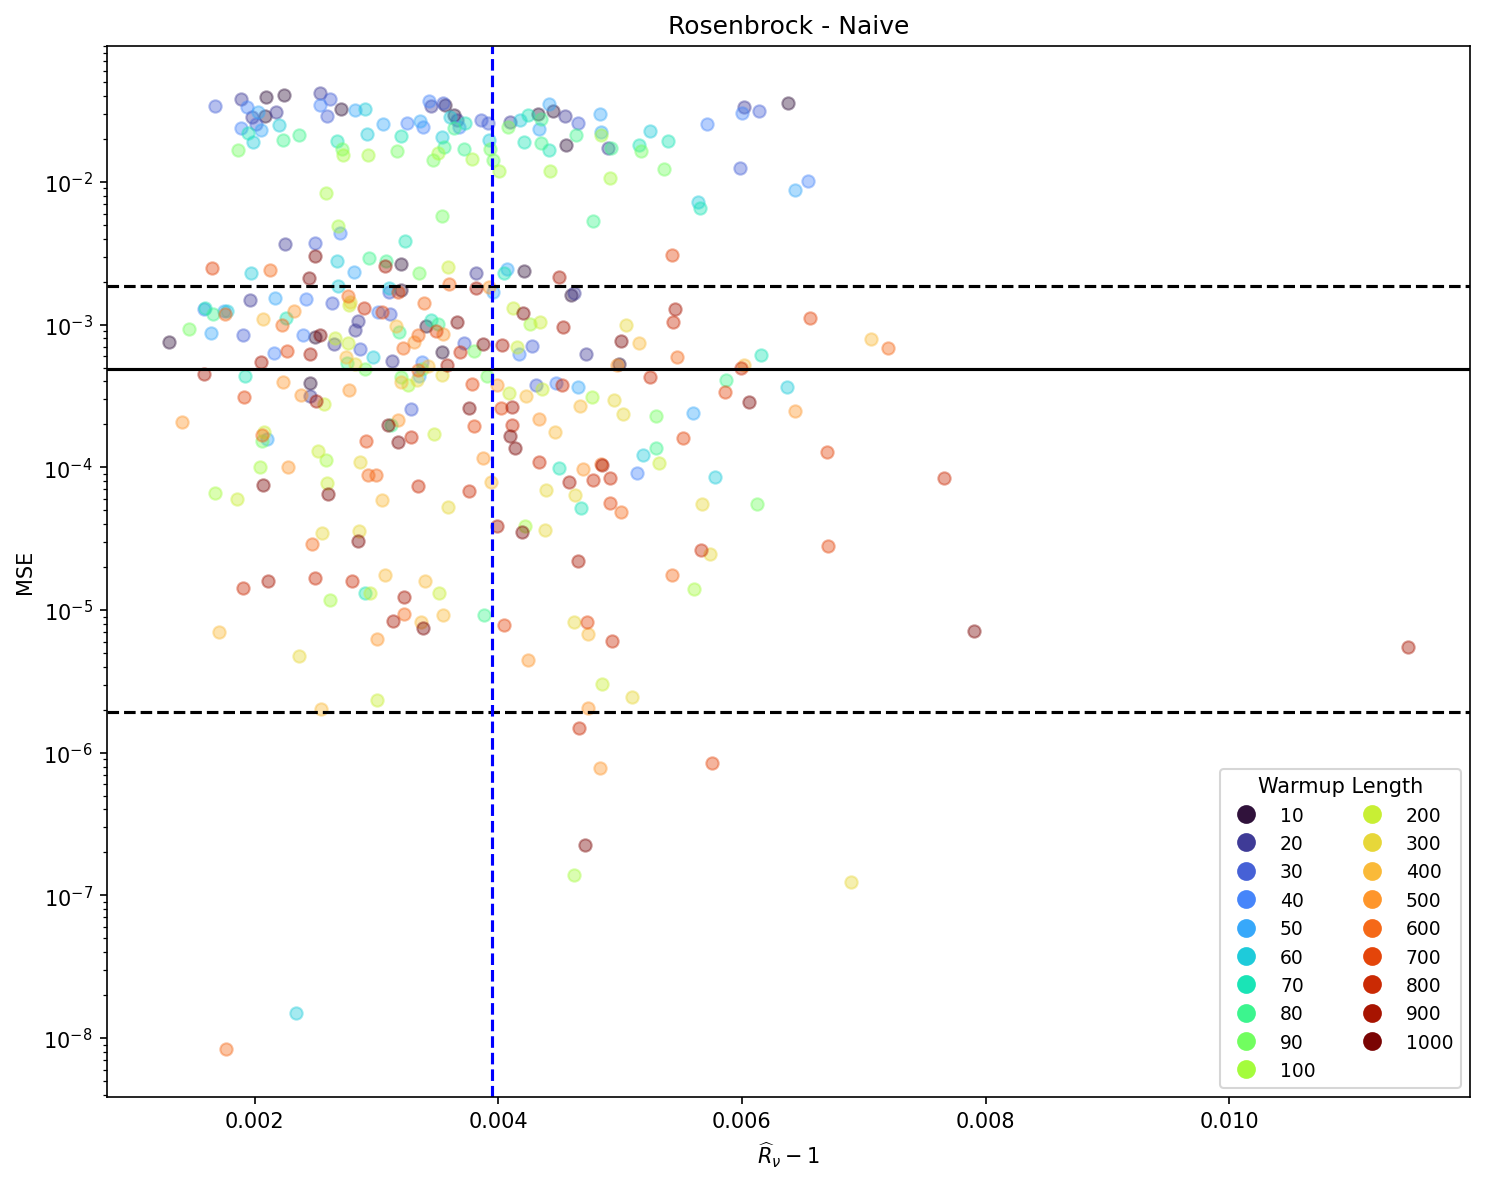

In [29]:
MSE_vs_Rhat(R_Hat_n_df,
           "Rosenbrock",
           True,
            bound, threshold,num_chains_short,False)

**Bimodal Plots**

### Load data

In [35]:
MSE_constrained_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/Bimodal_MSE_constrained.pkl"
Bimodal_MSE_c_df = pd.read_pickle(MSE_constrained_path)
MSE_naive_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/Bimodal_MSE_naive.pkl"
Bimodal_MSE_n_df = pd.read_pickle(MSE_naive_path)

R_hat_constrained_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/Bimodal_R_Hat_constrained.pkl"
Bimodal_R_Hat_c_df = pd.read_pickle(R_hat_constrained_path)
R_hat_naive_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/Bimodal_R_Hat_naive.pkl"
Bimodal_R_Hat_n_df = pd.read_pickle(R_hat_naive_path)

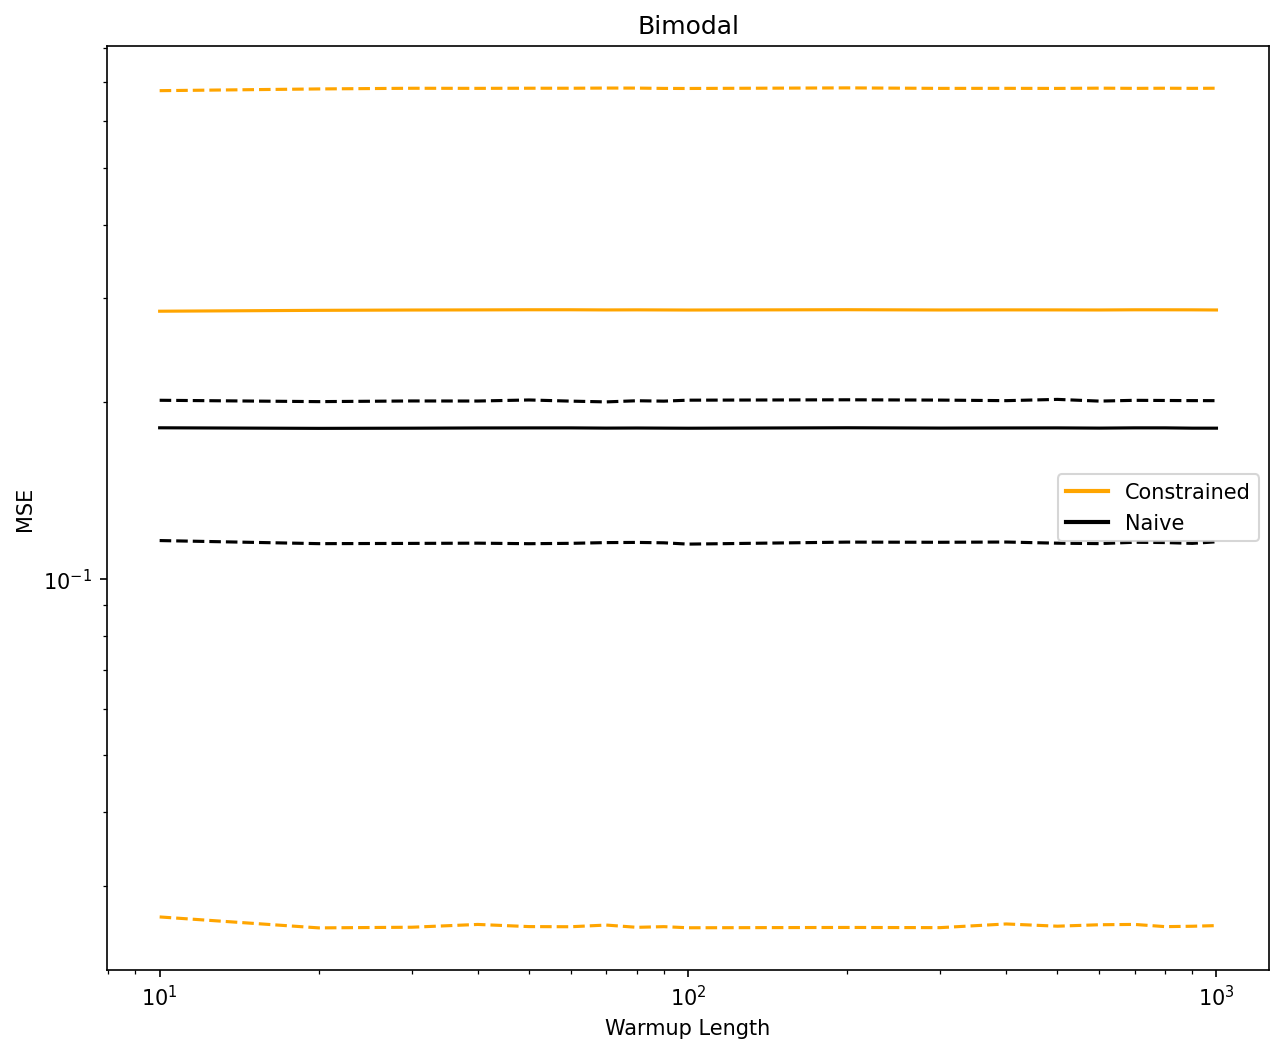

In [33]:
MSE_vs_Warmup(Bimodal_MSE_c_df, Bimodal_MSE_n_df,"Bimodal")

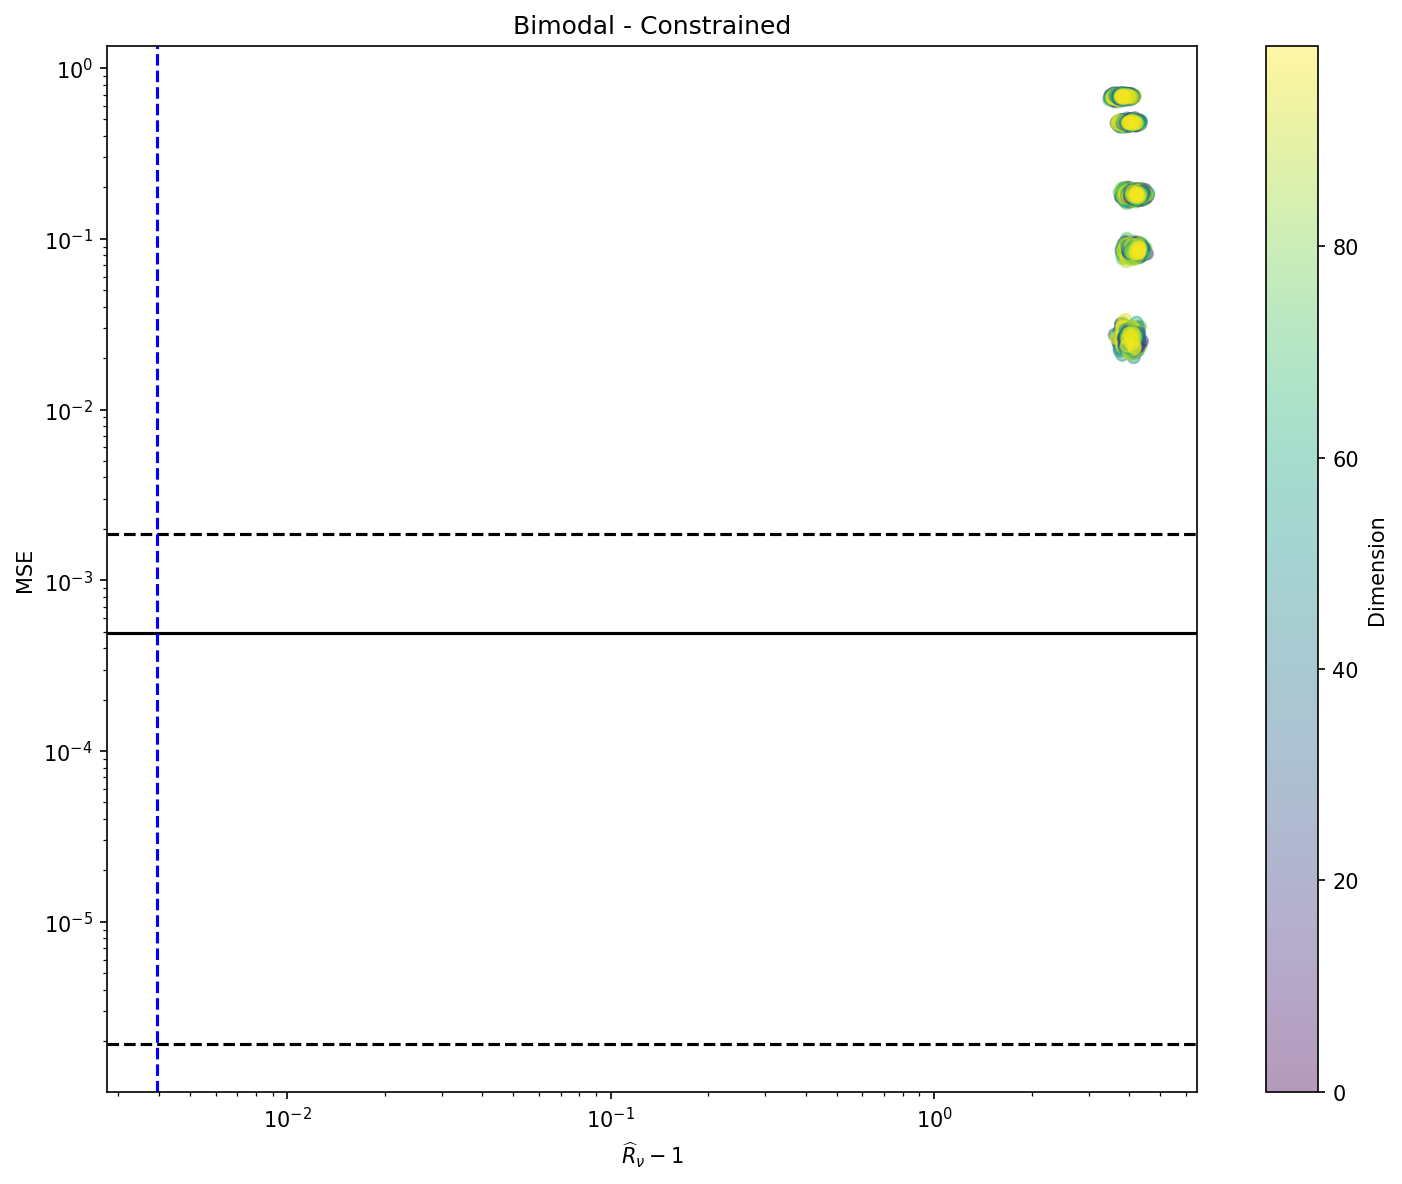

In [36]:
MSE_vs_Rhat(Bimodal_R_Hat_c_df,
           "Bimodal",
           False,
            bound, threshold,num_chains_short,True)

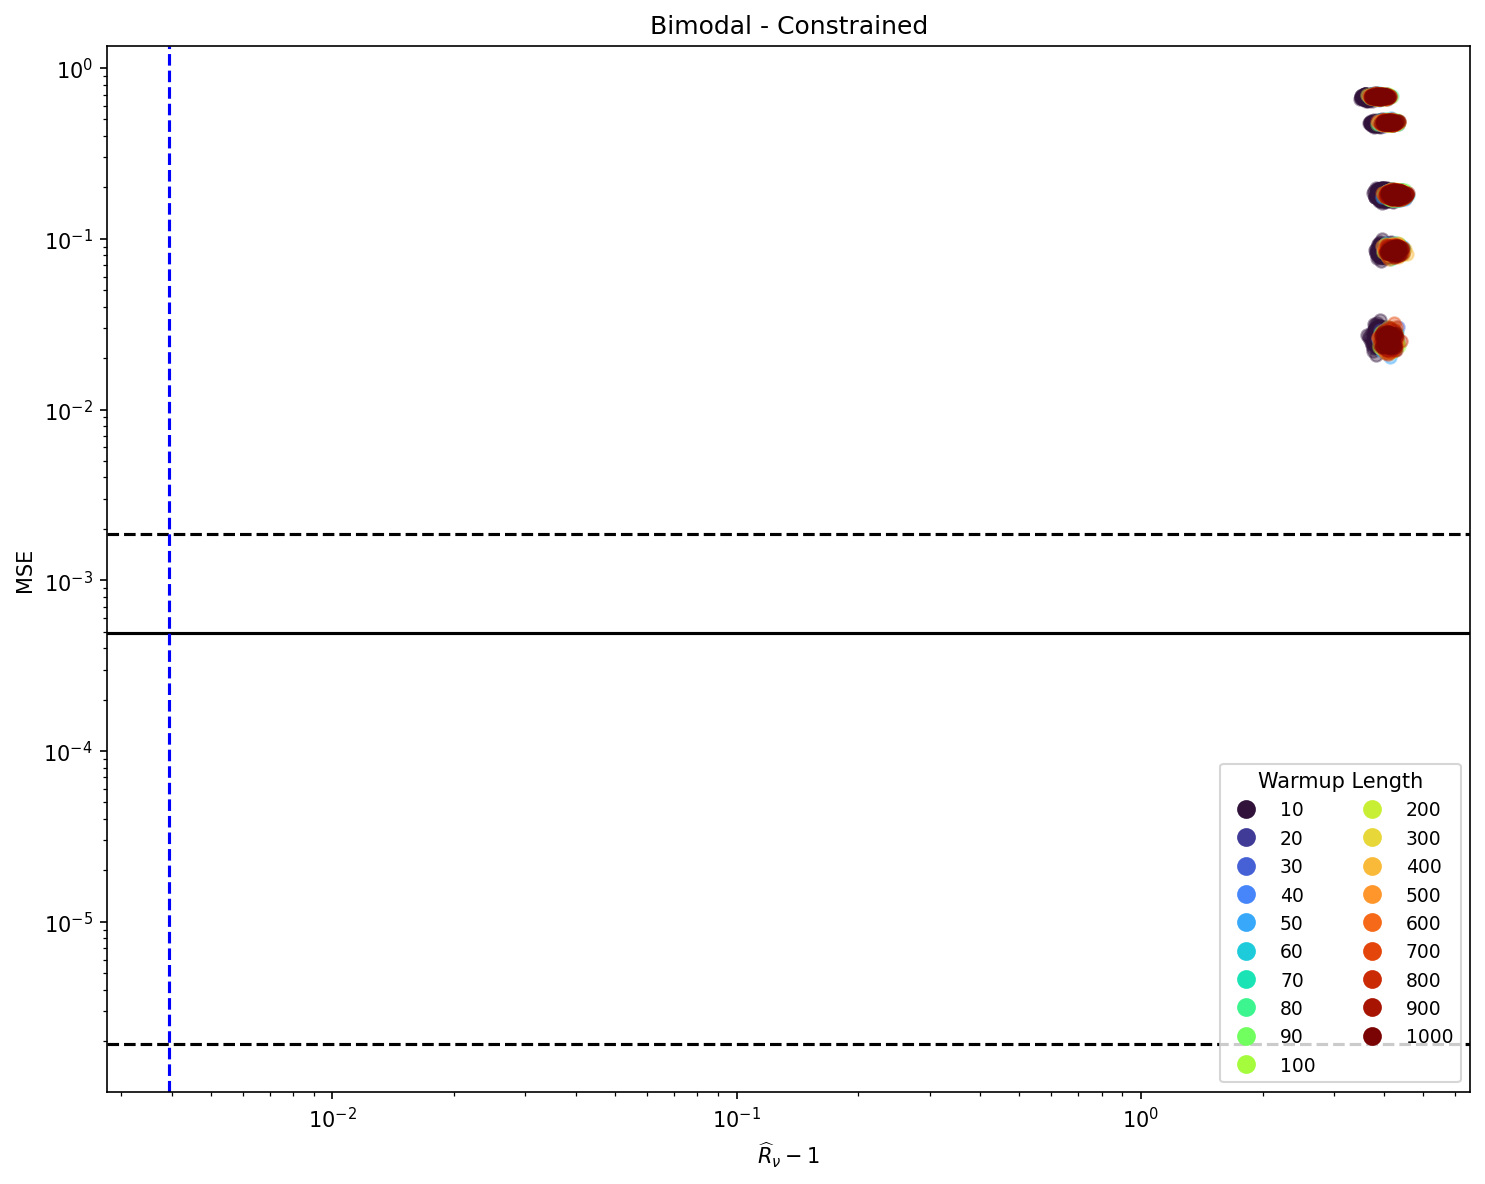

In [37]:
MSE_vs_Rhat(Bimodal_R_Hat_c_df,
           "Bimodal",
           False,
            bound, threshold,num_chains_short,False)

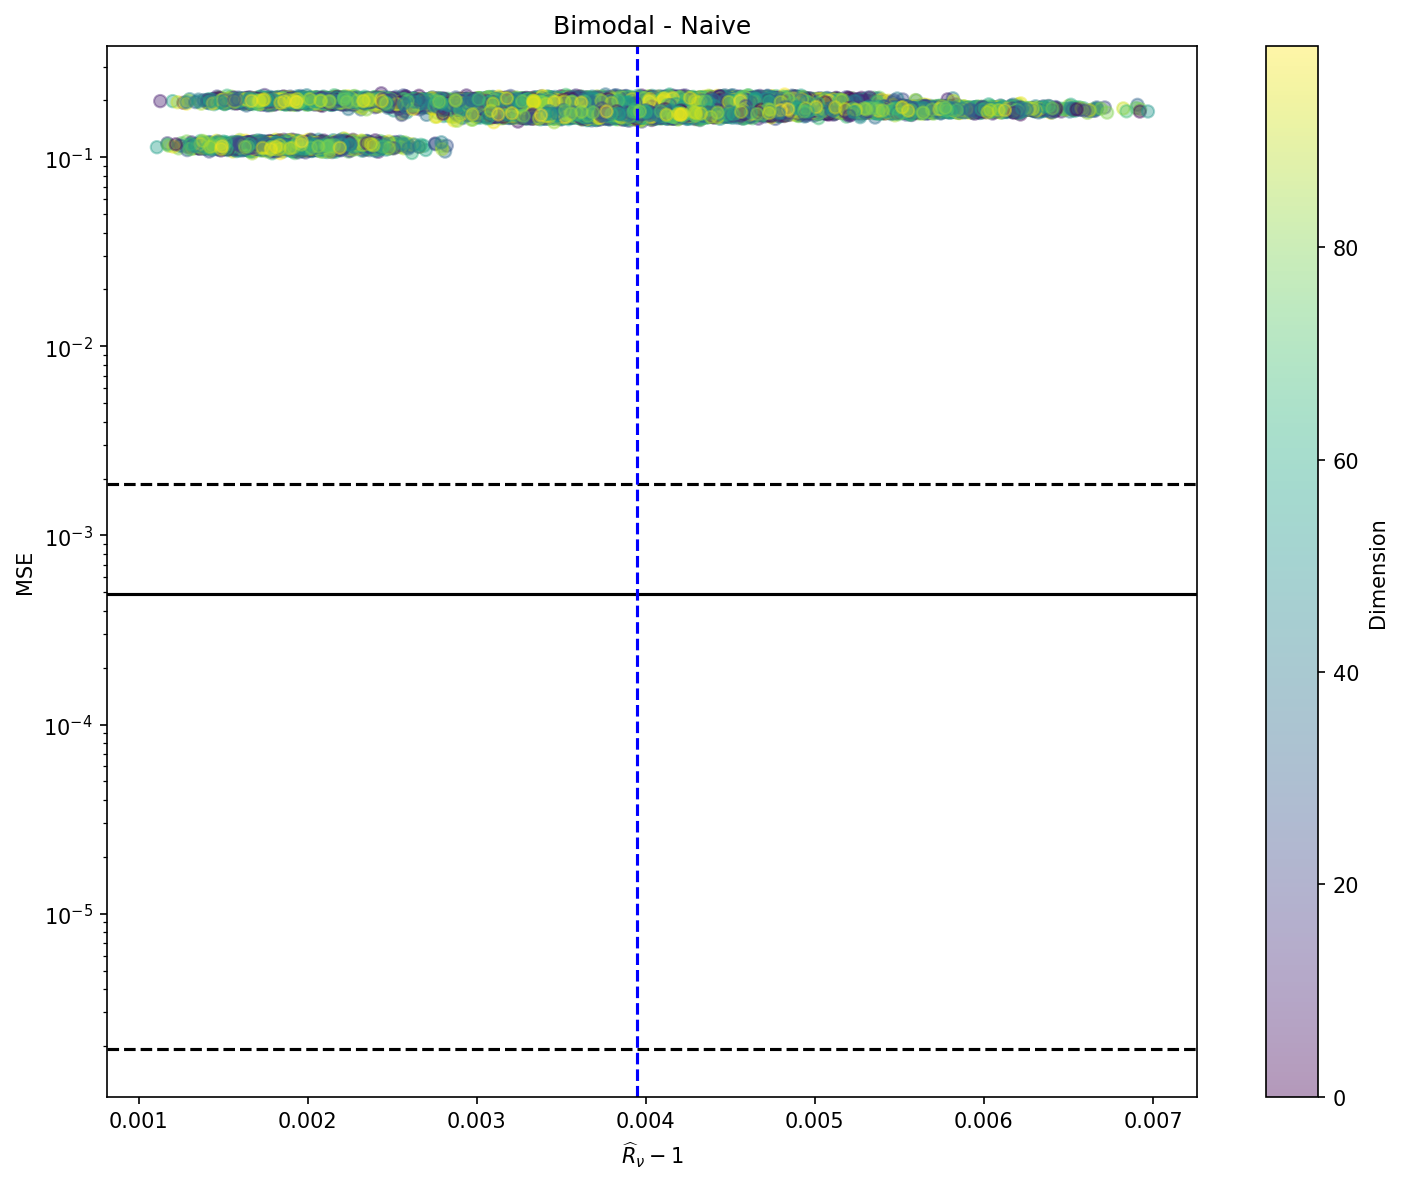

In [38]:
MSE_vs_Rhat(Bimodal_R_Hat_n_df,
           "Bimodal",
           True,
            bound, threshold,num_chains_short,True)

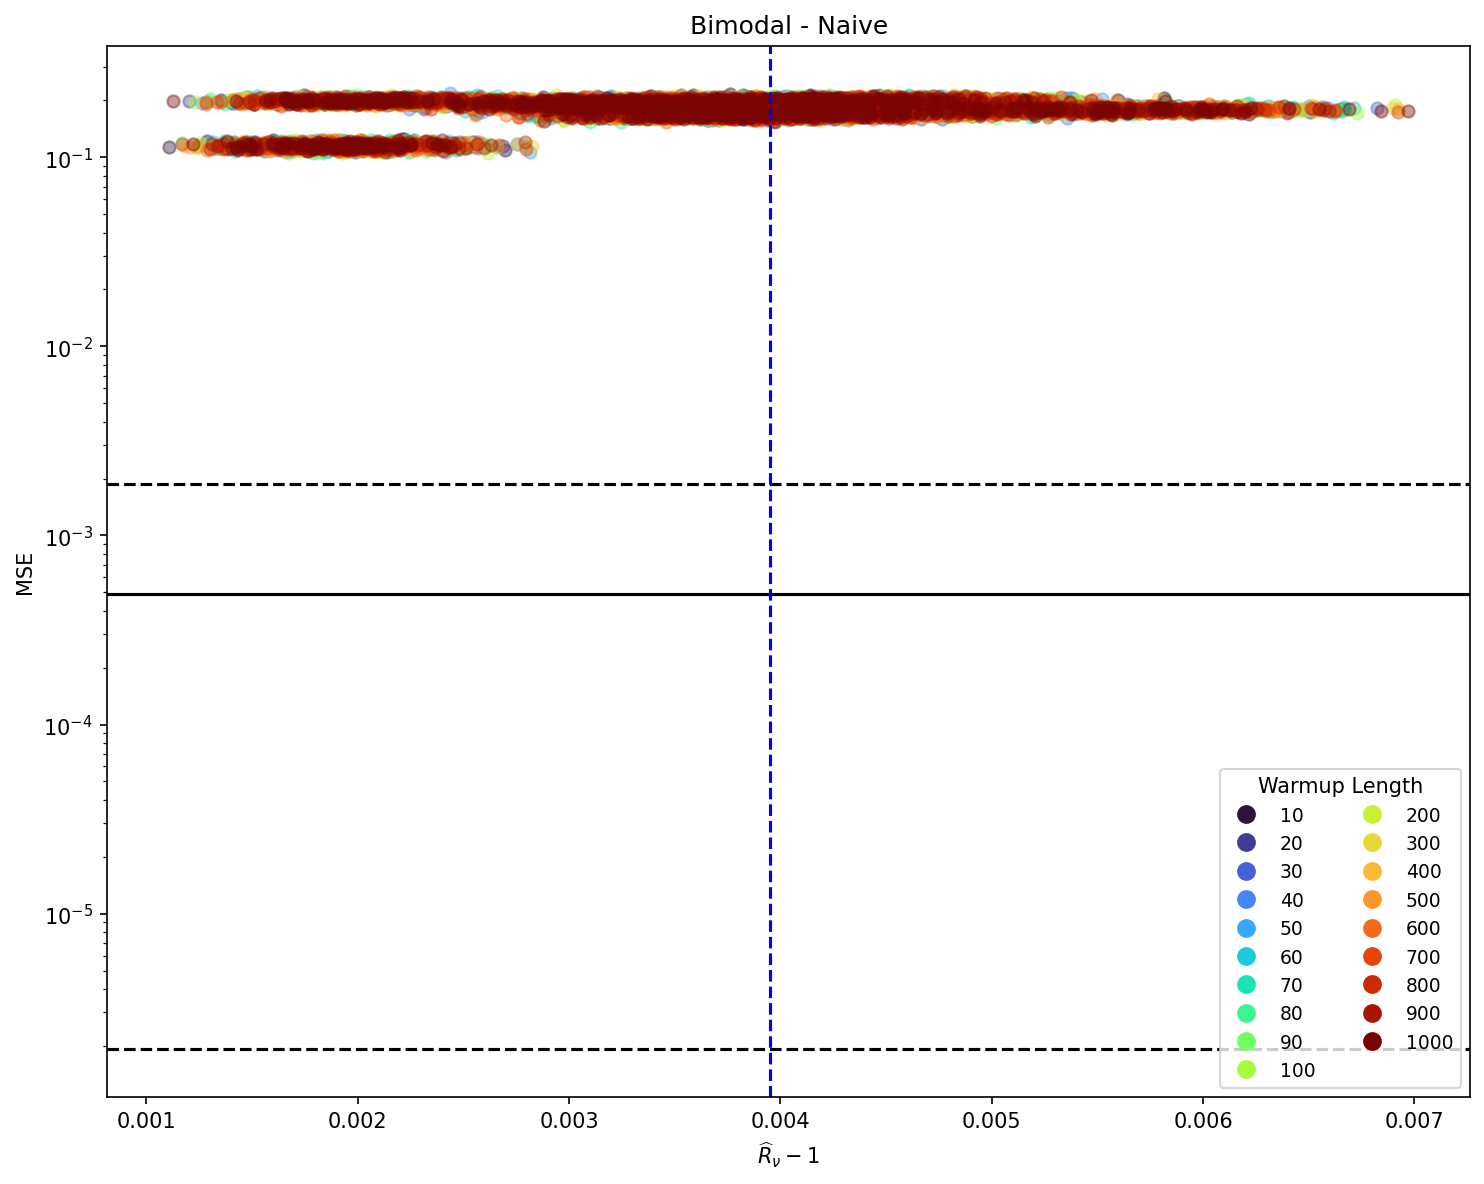

In [39]:
MSE_vs_Rhat(Bimodal_R_Hat_n_df,
           "Bimodal",
           True,
            bound, threshold,num_chains_short,False)

**Eight School Plots**

In [40]:
MSE_constrained_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/School_MSE_constrained.pkl"
School_MSE_c_df = pd.read_pickle(MSE_constrained_path)
MSE_naive_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/School_MSE_naive.pkl"
School_MSE_n_df = pd.read_pickle(MSE_naive_path)

R_hat_constrained_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/School_R_Hat_constrained.pkl"
School_R_Hat_c_df = pd.read_pickle(R_hat_constrained_path)
R_hat_naive_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/School_R_Hat_naive.pkl"
School_R_Hat_n_df = pd.read_pickle(R_hat_naive_path)

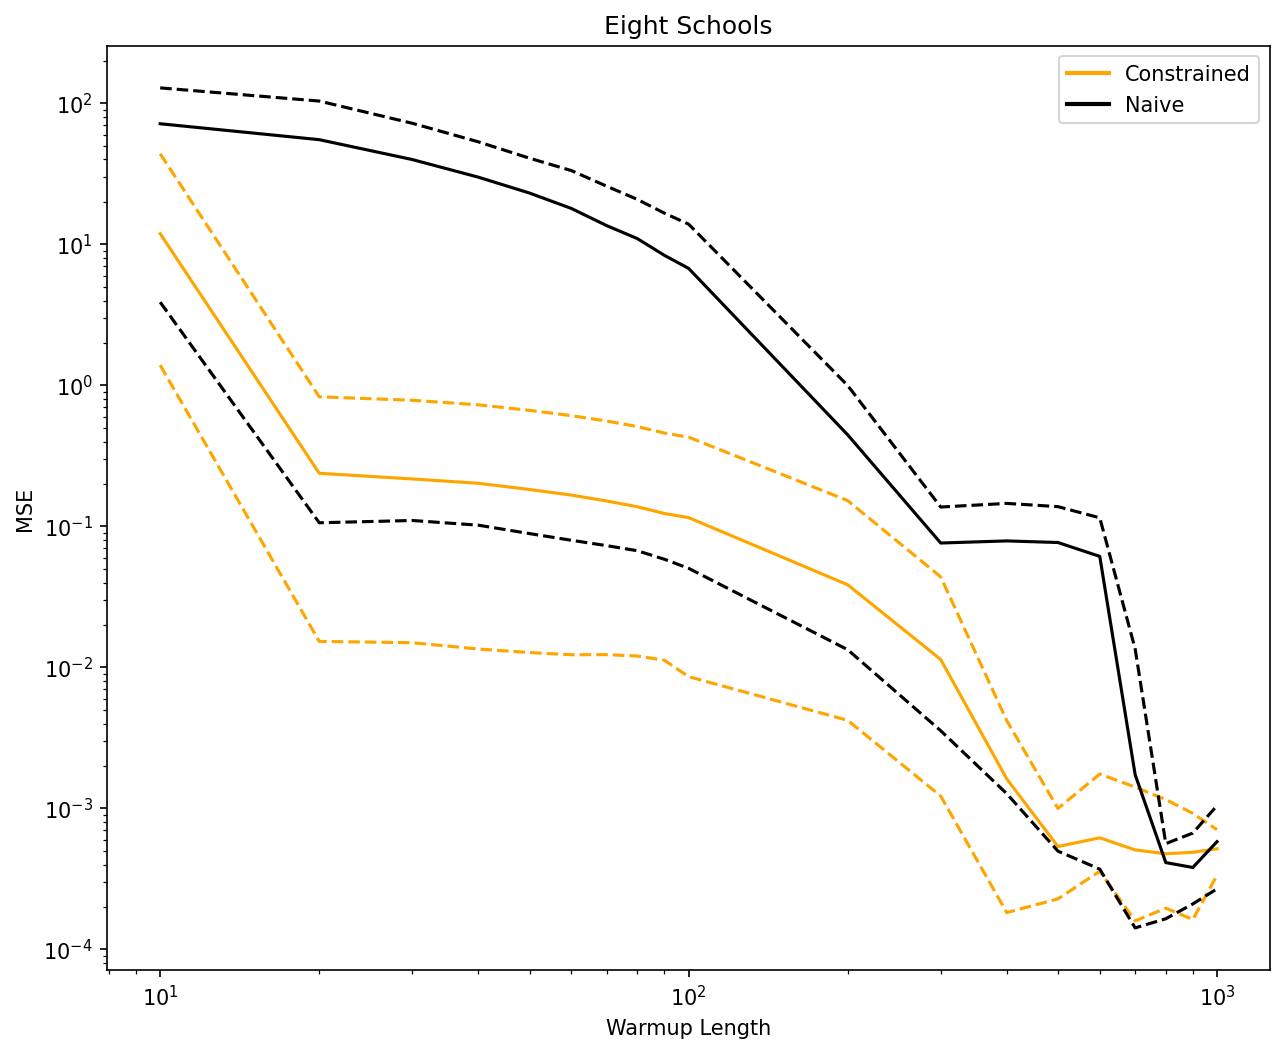

In [41]:
MSE_vs_Warmup(School_MSE_c_df, School_MSE_n_df,"Eight Schools")

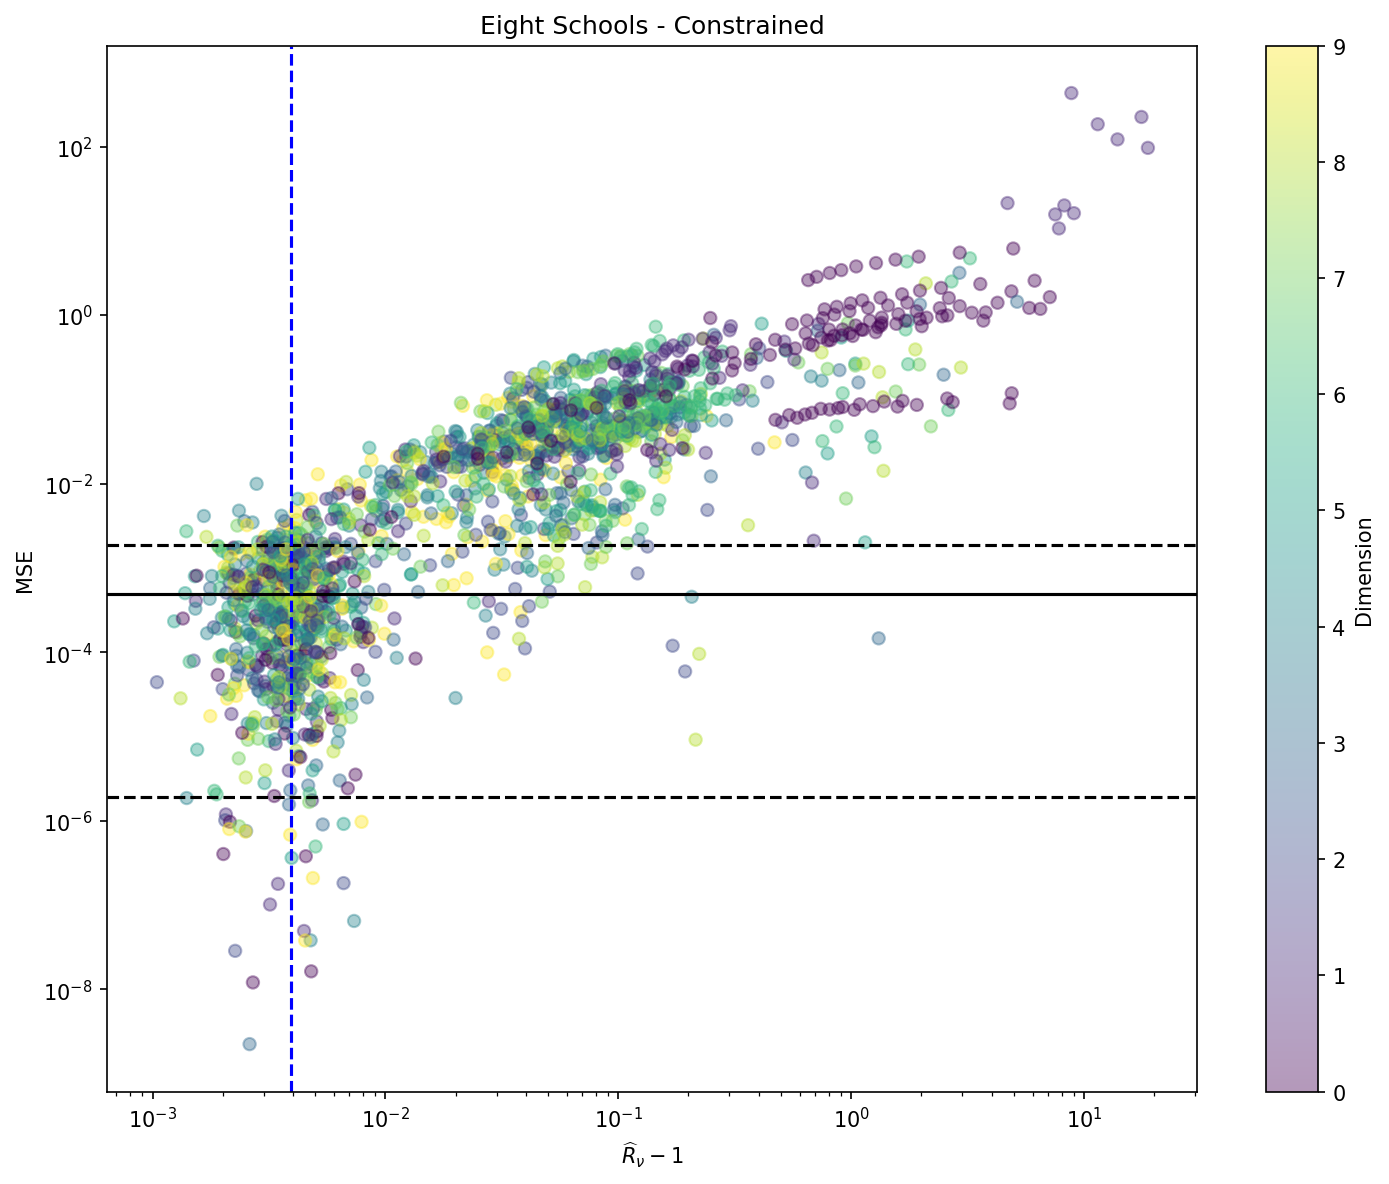

In [42]:
MSE_vs_Rhat(School_R_Hat_c_df,
           "Eight Schools",
           False,
            bound, threshold,num_chains_short,True)

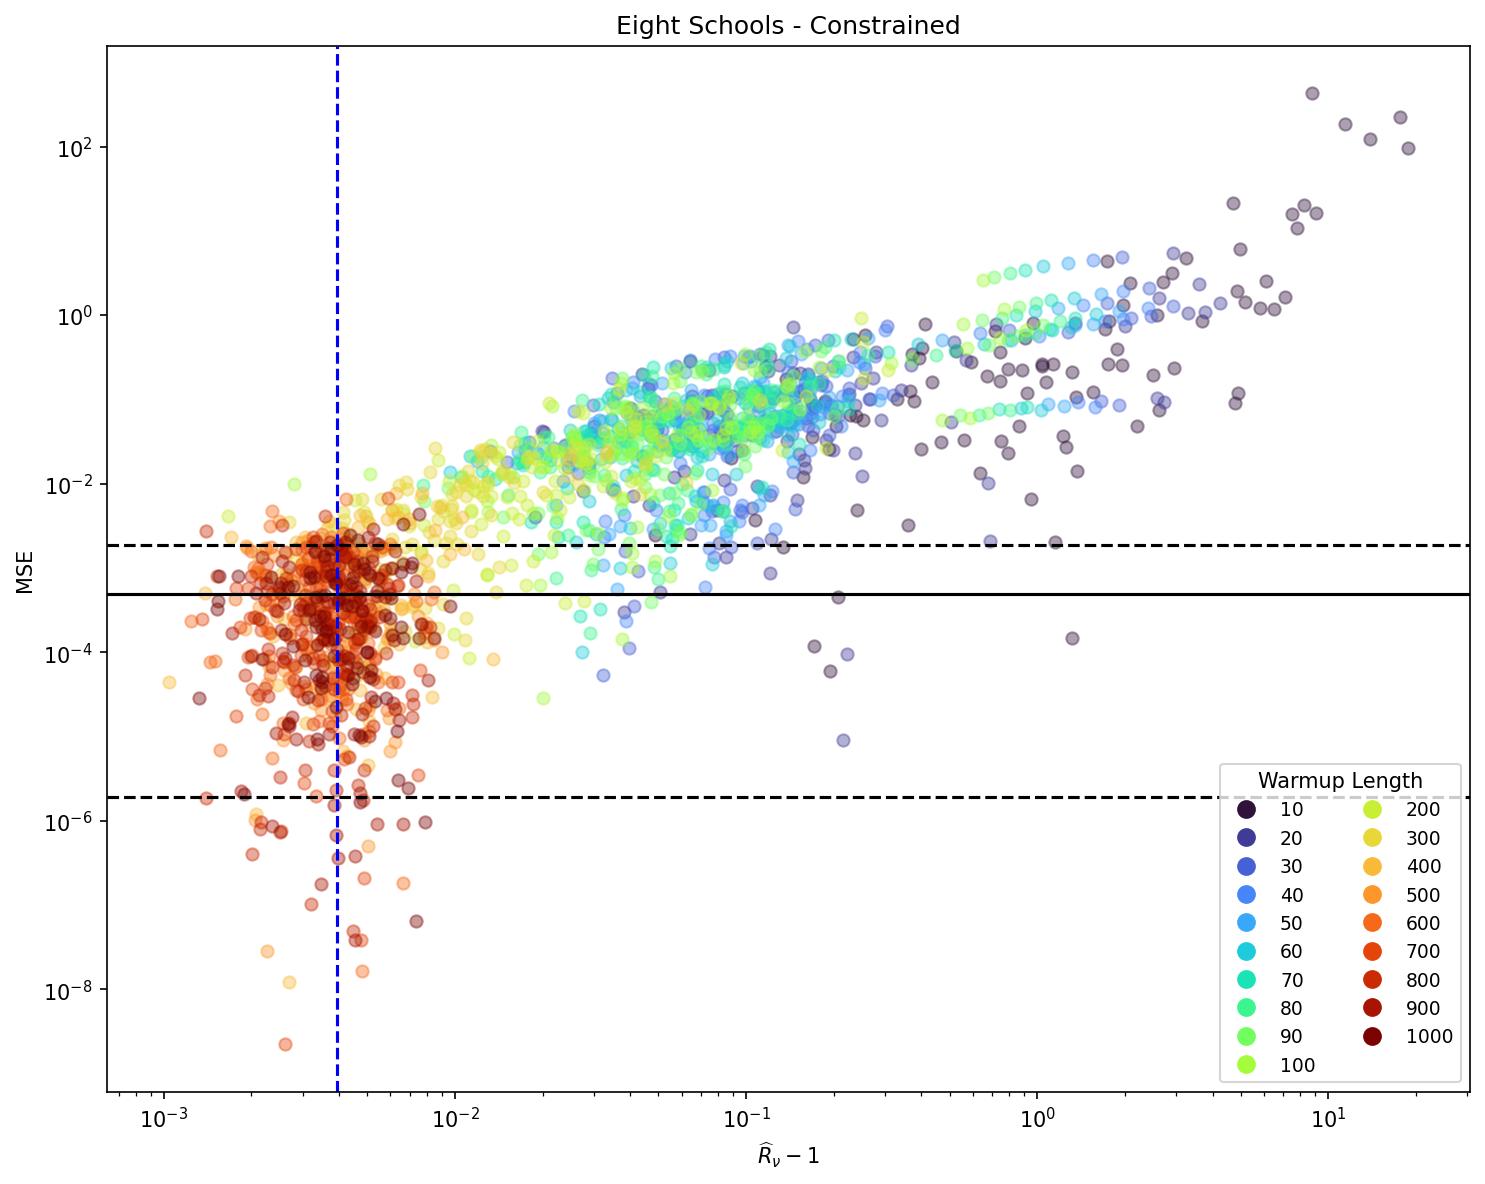

In [43]:
MSE_vs_Rhat(School_R_Hat_c_df,
           "Eight Schools",
           False,
            bound, threshold,num_chains_short,False)

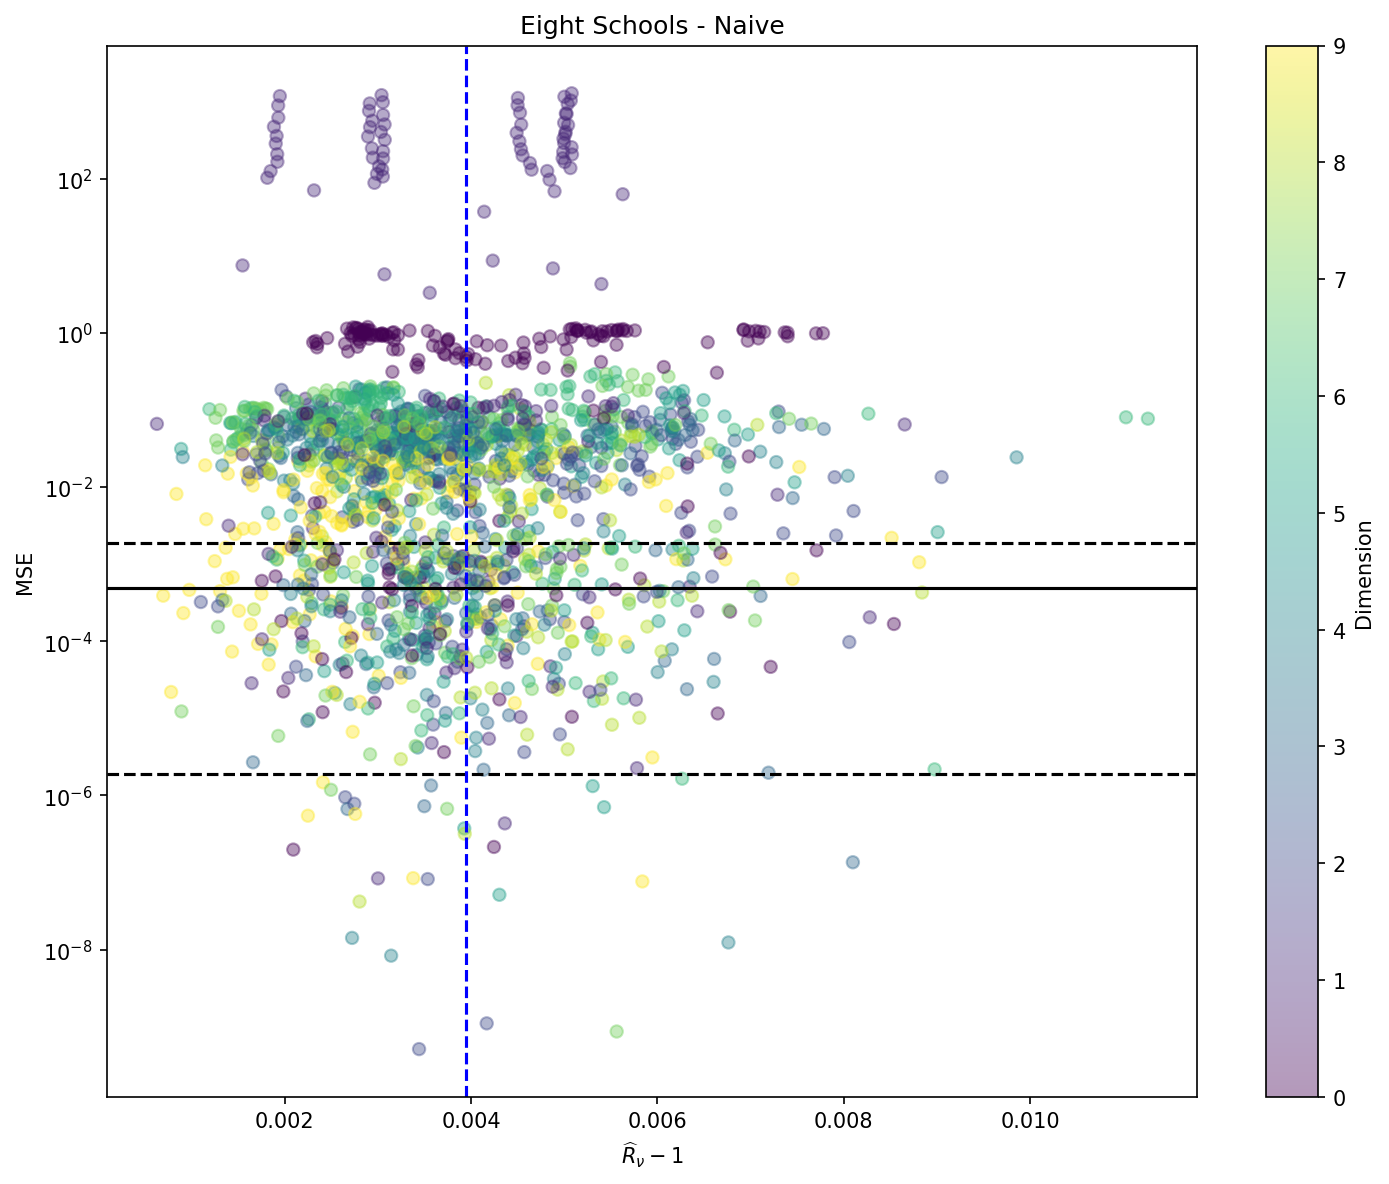

In [44]:
MSE_vs_Rhat(School_R_Hat_n_df,
           "Eight Schools",
           True,
            bound, threshold,num_chains_short,True)

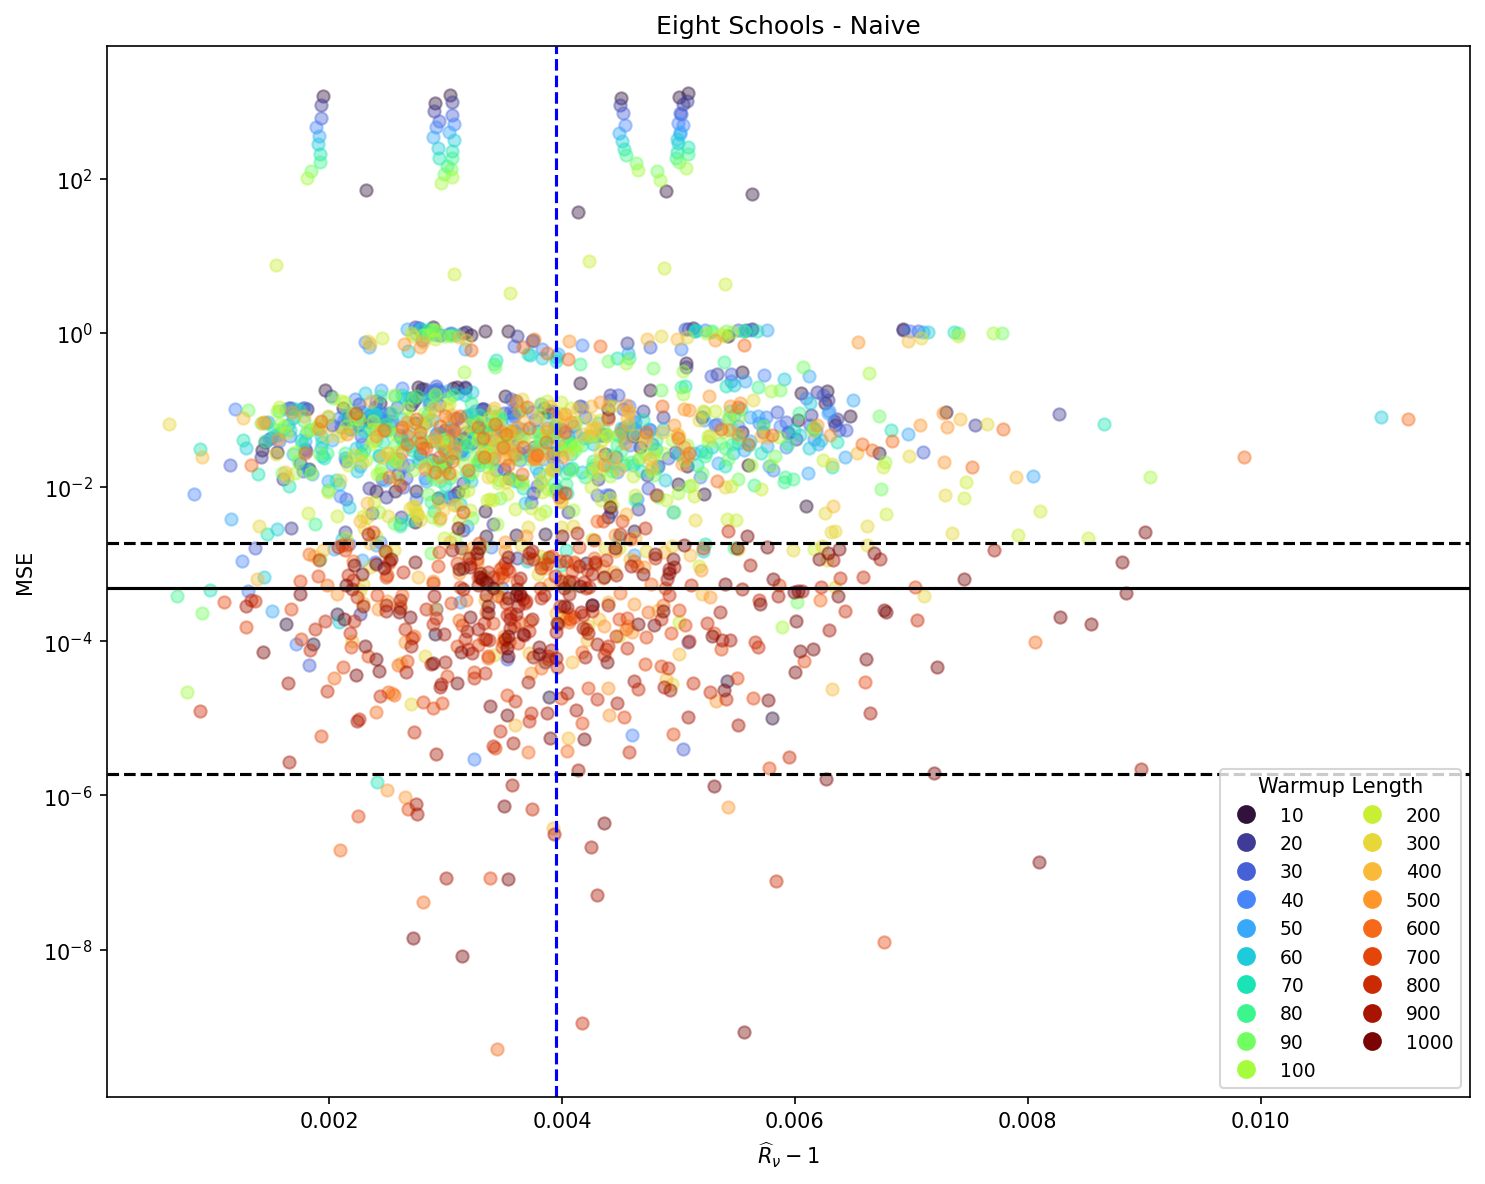

In [45]:
MSE_vs_Rhat(School_R_Hat_n_df,
           "Eight Schools",
           True,
            bound, threshold,num_chains_short,False)

**IRT Plot**

In [ ]:
MSE_constrained_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/IRT_MSE_constrained.pkl"
MSE_constrained_df = pd.read_pickle(MSE_constrained_path)
MSE_naive_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/IRT_MSE_naive.pkl"
MSE_naive_df = pd.read_pickle(MSE_naive_path)

R_hat_constrained_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/IRT_R_Hat_constrained.pkl"
R_hat_constrained_df = pd.read_pickle(R_hat_constrained_path)
R_hat_naive_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/IRT_R_Hat_naive.pkl"
R_hat_naive_df = pd.read_pickle(R_hat_naive_path)

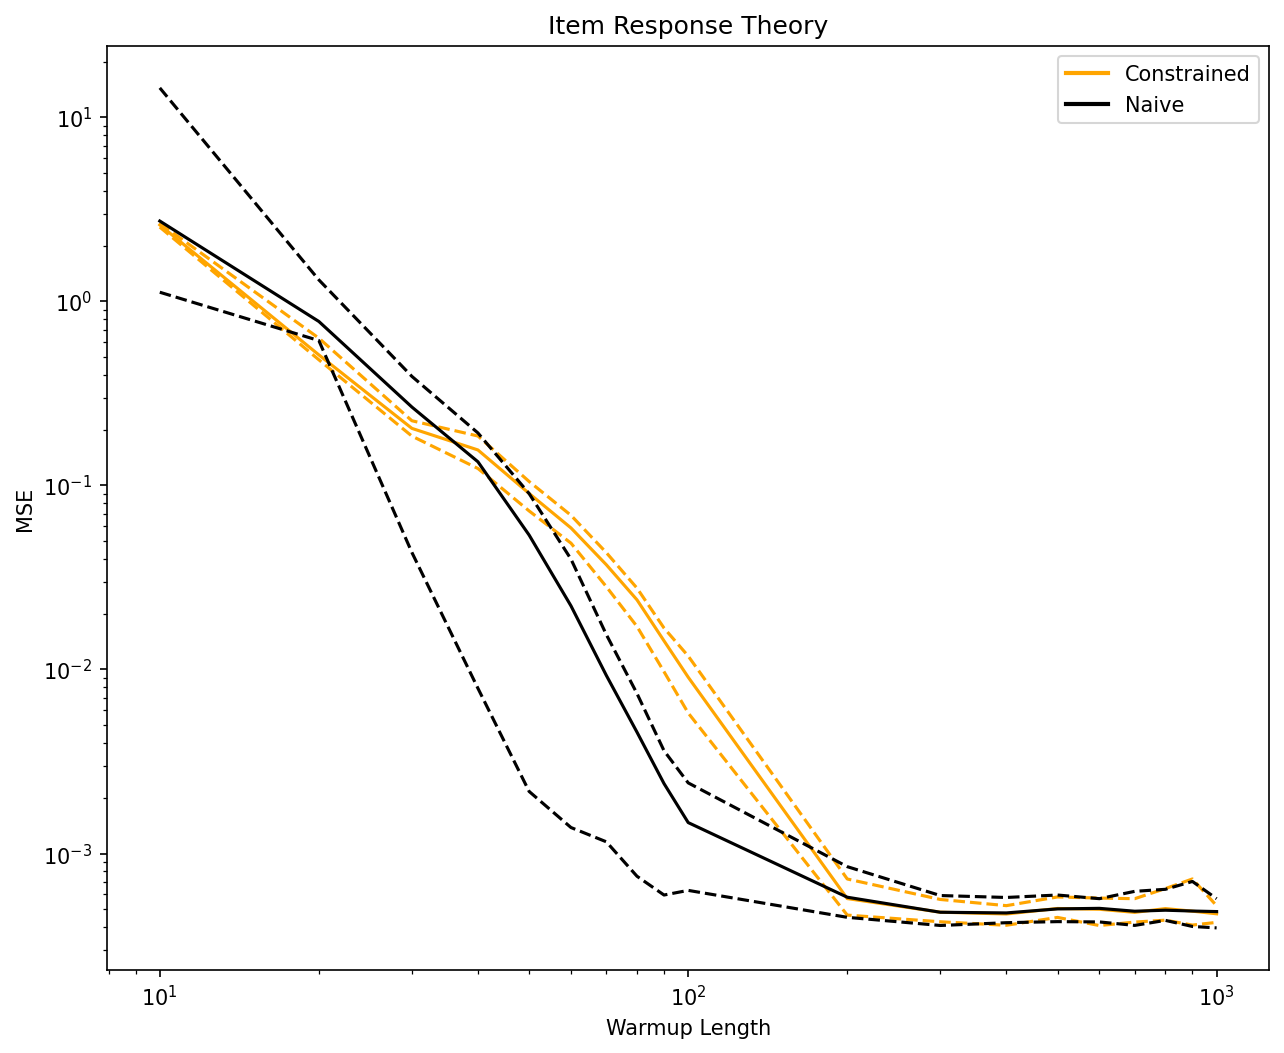

In [ ]:
MSE_vs_Warmup(MSE_constrained_df,MSE_naive_df,"Item Response Theory")

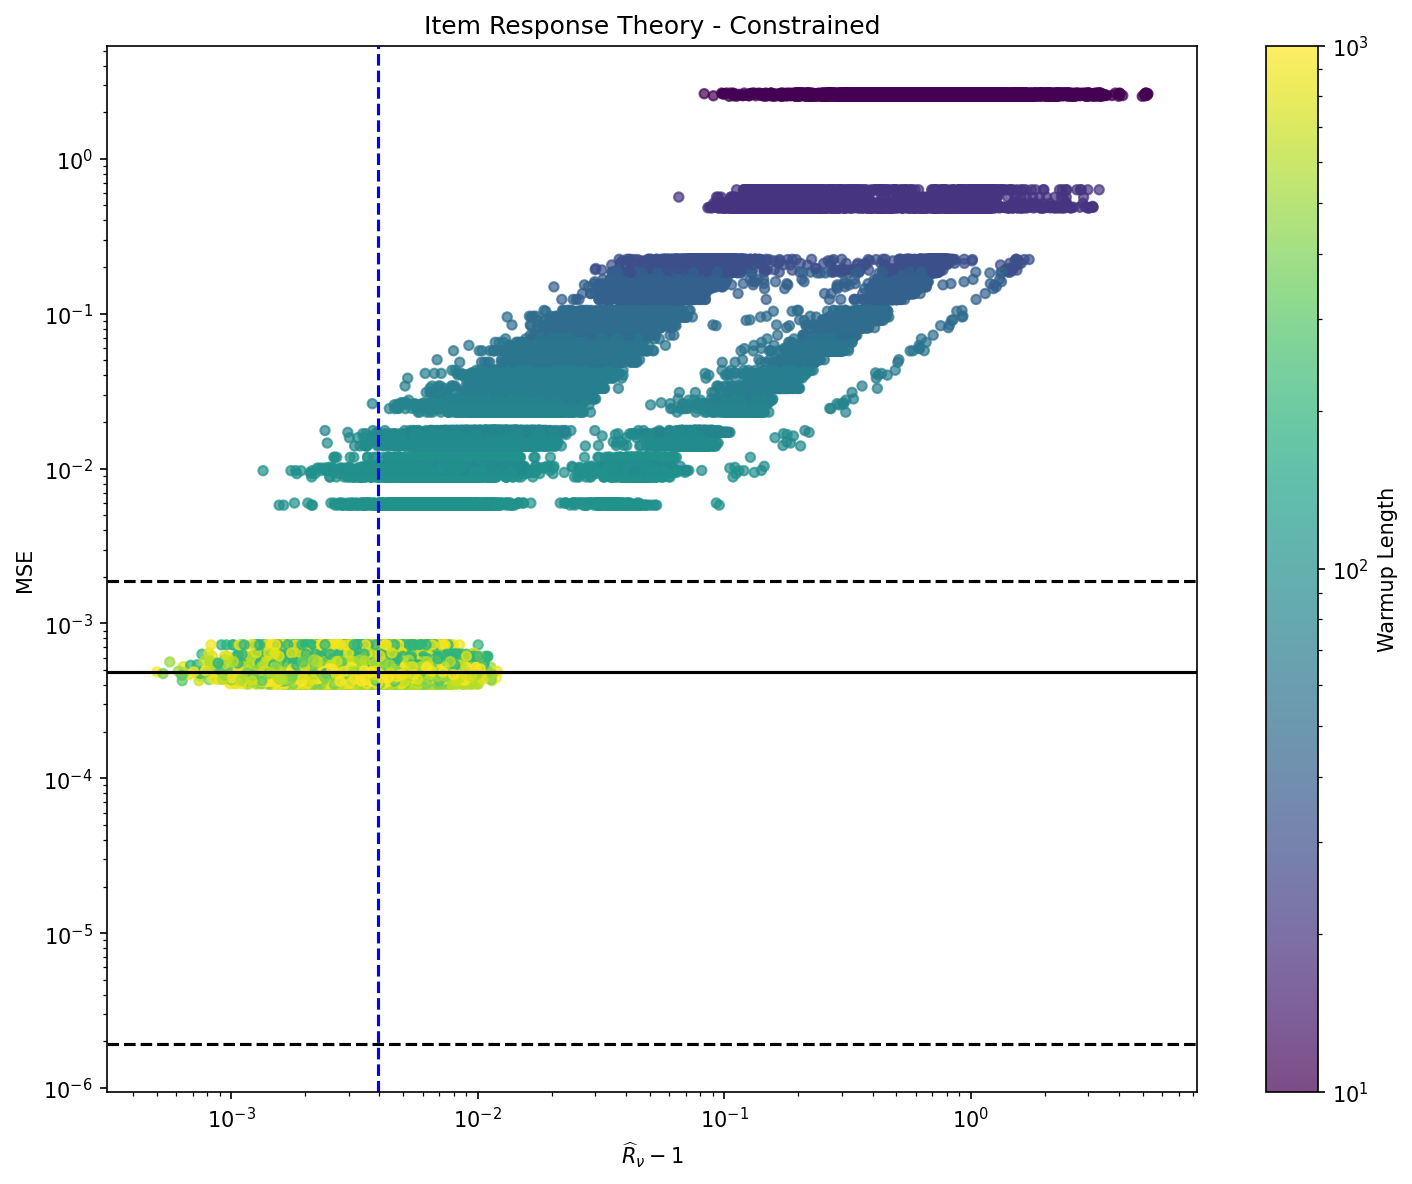

In [ ]:
MSE_vs_Rhat(R_hat_constrained_df, "Item Response Theory", naive=False)

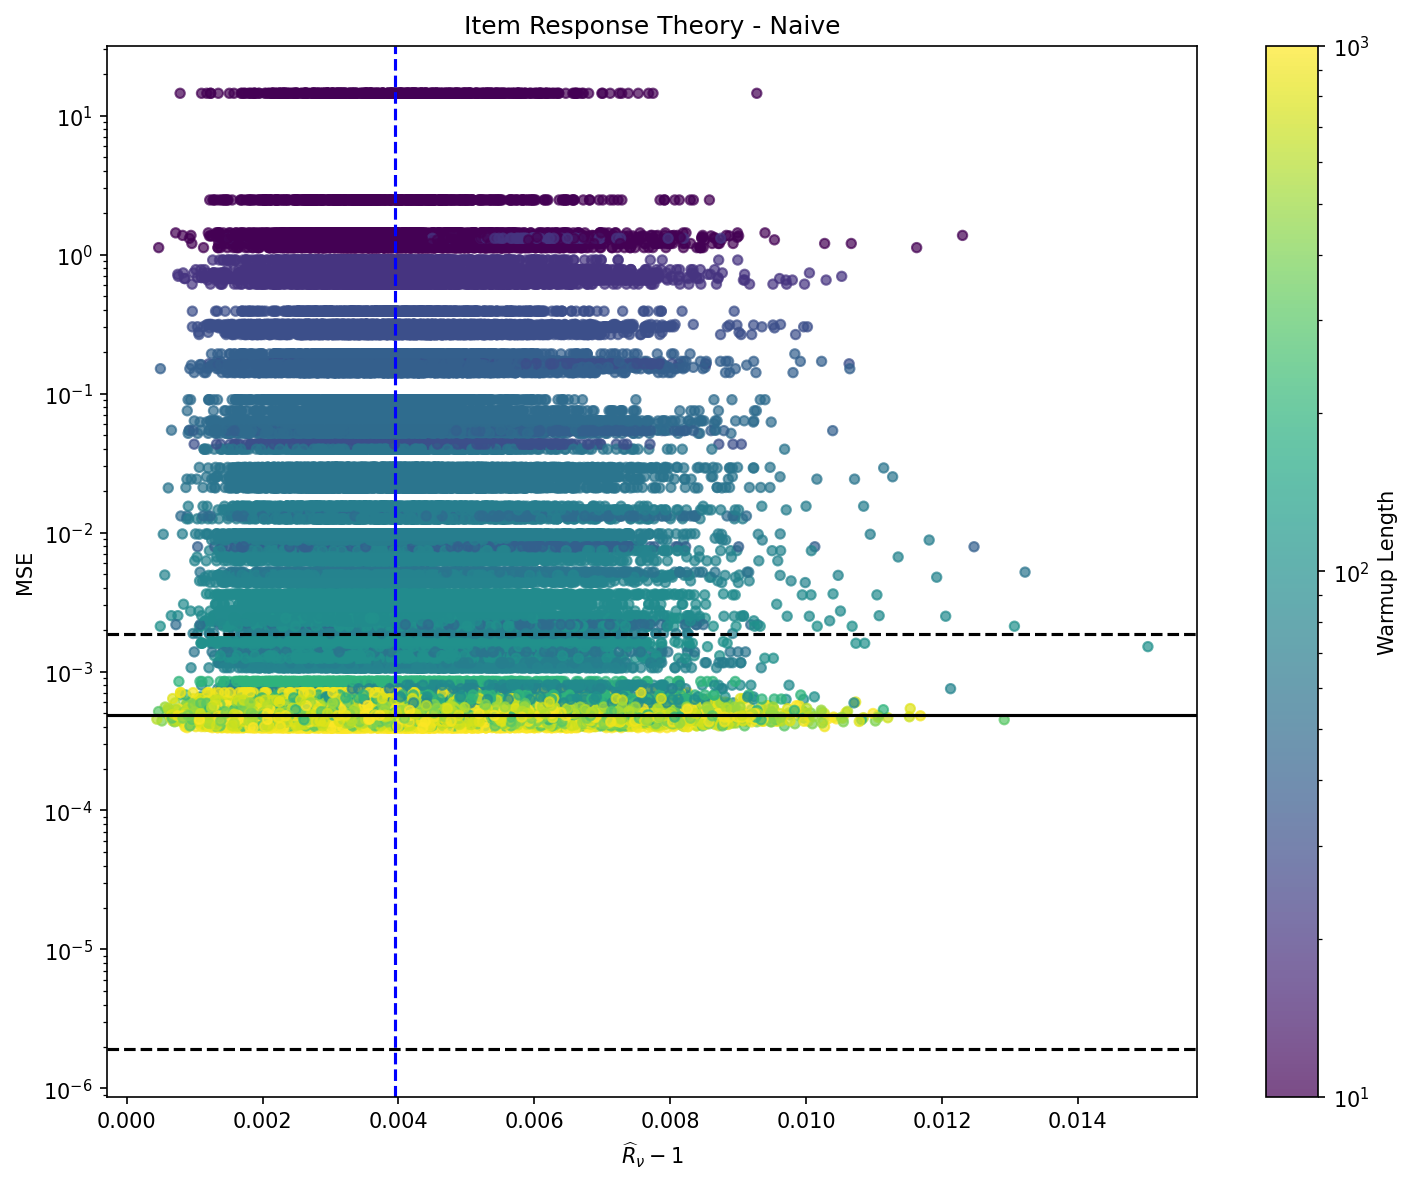

In [ ]:
MSE_vs_Rhat(R_hat_naive_df, "Item Response Theory", naive=True)

# Section for Initialization Experiment

**Load Data**

In [ ]:
GMM_MSE_constrained_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/GMM_MSE_constrained.pkl"
GMM_MSE_constrained_df = pd.read_pickle(GMM_MSE_constrained_path)
GMM_MSE_naive_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/GMM_MSE_naive.pkl"
GMM_MSE_naive_df = pd.read_pickle(GMM_MSE_naive_path)

GMM_R_hat_constrained_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/GMM_R_Hat_constrained.pkl"
GMM_R_hat_constrained_df = pd.read_pickle(GMM_R_hat_constrained_path)
GMM_R_hat_naive_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/GMM_R_Hat_naive.pkl"
GMM_R_hat_naive_df = pd.read_pickle(GMM_R_hat_naive_path)

In [ ]:
MVN_MSE_constrained_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/MVN_MSE_constrained.pkl"
MVN_MSE_constrained_df = pd.read_pickle(MVN_MSE_constrained_path)
MVN_MSE_naive_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/MVN_MSE_naive.pkl"
MVN_MSE_naive_df = pd.read_pickle(MVN_MSE_naive_path)

MVN_R_hat_constrained_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/MVN_R_Hat_constrained.pkl"
MVN_R_hat_constrained_df = pd.read_pickle(MVN_R_hat_constrained_path)
MVN_R_hat_naive_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/MVN_R_Hat_naive.pkl"
MVN_R_hat_naive_df = pd.read_pickle(MVN_R_hat_naive_path)

**Helper Functions**

In [ ]:
def MSE_vs_Rhat(df, title, naive):

    df_copy = deepcopy(df)

    # Shift all R-hat columns by 1
    rhat_cols = [c for c in df_copy.columns if c.startswith("r_hat_")]
    df_copy[rhat_cols] = df_copy[rhat_cols] - 1

    fig, ax = plt.subplots(figsize=(10, 8), dpi=150)
    long_df = df_copy.melt(
    id_vars=["MSE", "Number of Dimensions", "Warmup Length"],
    value_vars=rhat_cols,
    var_name="Rhat Column",
    value_name="Rhat"
    )
    groups = long_df.groupby(["Number of Dimensions", "Warmup Length"])


    # Marker for each dimension
    marker_map = {
        50: "o",
        80: "s",
        100: "^",
        200: "D",
        500: "*"
    }

    # Color for each warmup length
    color_map = {
    10: "tab:blue",
    25: "tab:cyan",
    50: "tab:green",
    75: "tab:orange",
    100: "tab:red"
    }

    # Plot every combination of dimension and warmup length
    for (dim, warmup), subset in groups:
      marker = marker_map[dim]
      color = color_map[warmup]

      ax.scatter(
        subset["Rhat"],
        subset["MSE"],
        marker=marker,
        color=color,
        s=35,
        alpha=0.4,
      )
    ax.set_yscale("log")
    if not naive:
        ax.set_xscale("log")

    ax.axhline(y=chi_up / num_chains_short, color="black", linestyle="--")
    ax.axhline(y=chi_lo / num_chains_short, color="black", linestyle="--")
    ax.axhline(y=1 / num_chains_short, color="black")
    ax.axvline(x=eps_lower, color="blue", linestyle="--")

    ax.set_xlabel(r"$\widehat{R}_{\nu}-1$")
    ax.set_ylabel("MSE")

    if not naive:
        ax.set_title(f"{title} - Constrained")
    else:
        ax.set_title(f"{title} - Naive")

    # Legend for dimensions (marker shapes)
    dim_handles = [
        Line2D([0], [0],
               marker=marker,
               color="black",
               linestyle="",
               markersize=8,
               label=f"{dim}")
        for dim, marker in marker_map.items()
    ]

    # Legend for warmup lengths (colors)
    warmup_handles = [
        Line2D([0], [0],
               marker="o",
               color=color,
               linestyle="",
               markersize=8,
               label=f"{warmup}")
        for warmup, color in color_map.items()
    ]

    legend1 = ax.legend(handles=dim_handles, title="Dimension",
                        loc="upper left")
    ax.add_artist(legend1)

    ax.legend(handles=warmup_handles, title="Warmup Length",
              loc="lower right")

    plt.tight_layout()
    plt.show()

In [ ]:
def MSE_line(constrained_df, naive_df, title, xax):

    dimRange = [50, 80, 100, 200, 500]

    fig, axes = plt.subplots(2, 3, figsize=(15, 10), dpi=150)
    axes = axes.flatten()

    for ax, dim in zip(axes, dimRange):

        constrained = constrained_df[
            constrained_df["Number of Dimension"] == dim
        ]

        naive = naive_df[
            naive_df["Number of Dimension"] == dim
        ]

        common = dict(
            x=xax,
            logx=True,
            logy=True,
            legend=False,
            ax=ax,
            ylabel="MSE",
        )

        # Constrained
        constrained.plot(
            y="Avg MSE",
            linestyle="-",
            color="orange",
            **common
        )

        constrained.plot(
            y="Best MSE",
            linestyle="--",
            color="orange",
            **common
        )

        constrained.plot(
            y="Worst MSE",
            linestyle="--",
            color="orange",
            **common
        )

        # Naive
        naive.plot(
            y="Avg MSE",
            linestyle="-",
            color="black",
            **common
        )

        naive.plot(
            y="Best MSE",
            linestyle="--",
            color="black",
            **common
        )

        naive.plot(
            y="Worst MSE",
            linestyle="--",
            color="black",
            **common
        )

        ax.set_title(f"Dimension = {dim}")
        ax.set_xlabel("Warmup Length")

    # Hide the unused subplot
    axes[-1].set_visible(False)

    # One legend for the whole figure
    fig.legend(
        handles=[
            Line2D([0], [0], color="orange", lw=2, label="Constrained"),
            Line2D([0], [0], color="black", lw=2, label="Naive"),
        ],
        loc="upper center",
        ncol=2,
    )

    fig.suptitle(title, fontsize=16)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

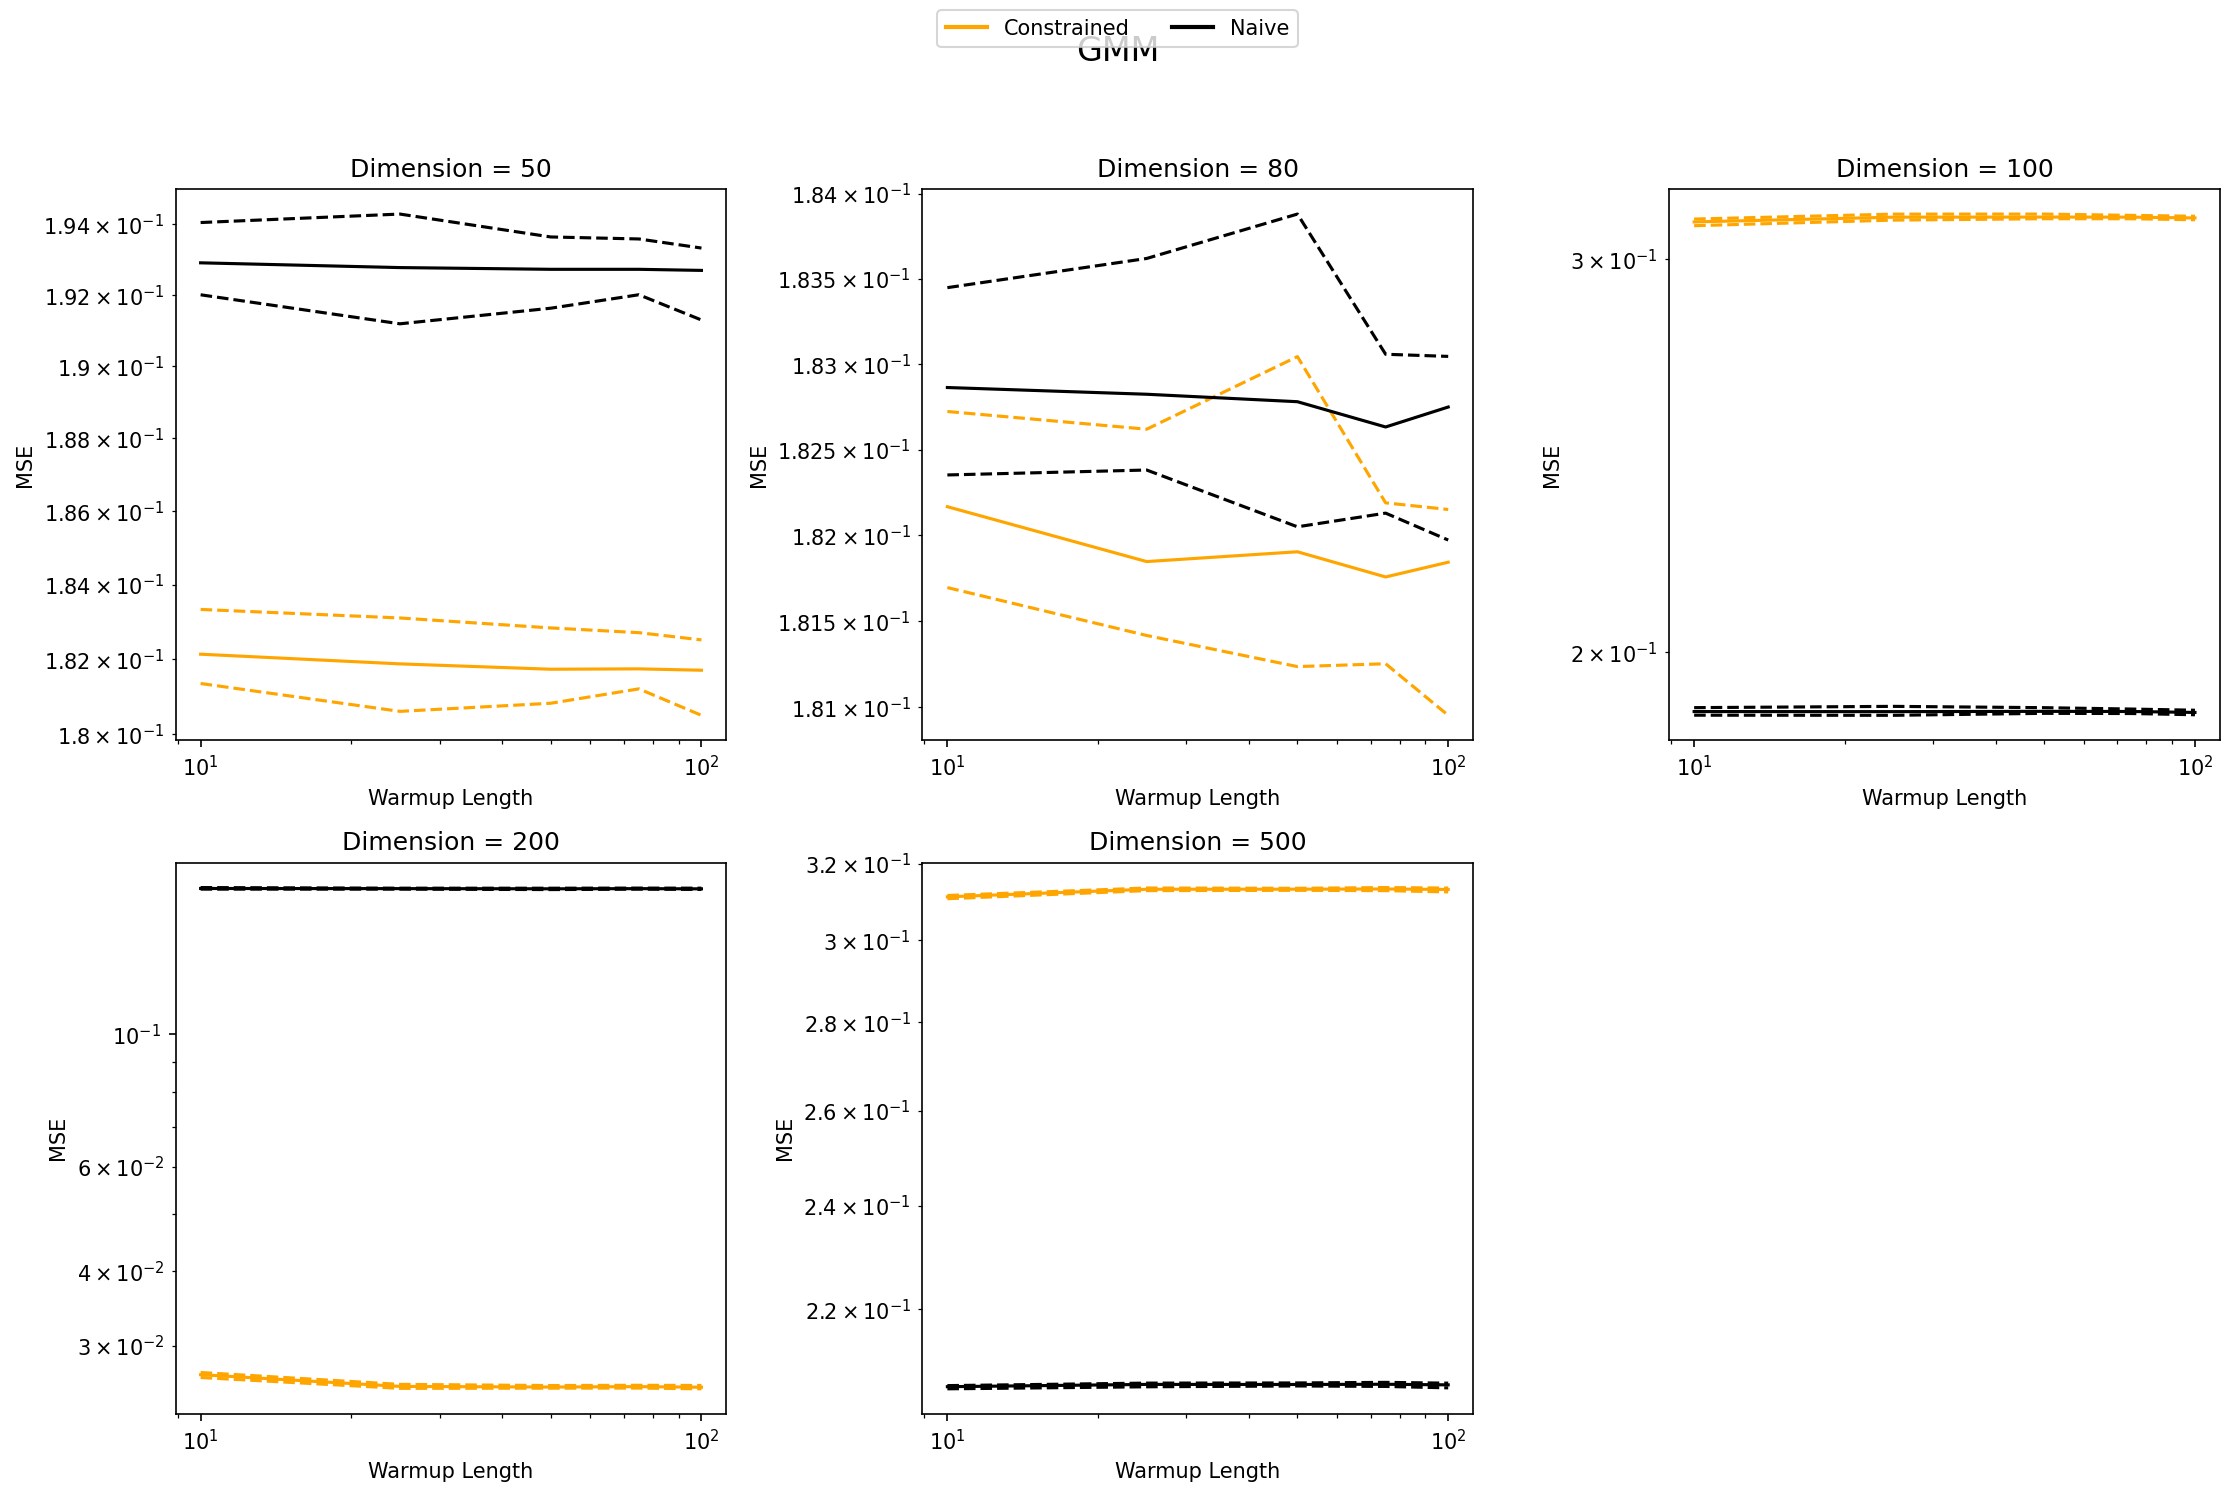

In [ ]:
MSE_line(GMM_MSE_constrained_df,GMM_MSE_naive_df,"GMM", "Warmup Length")

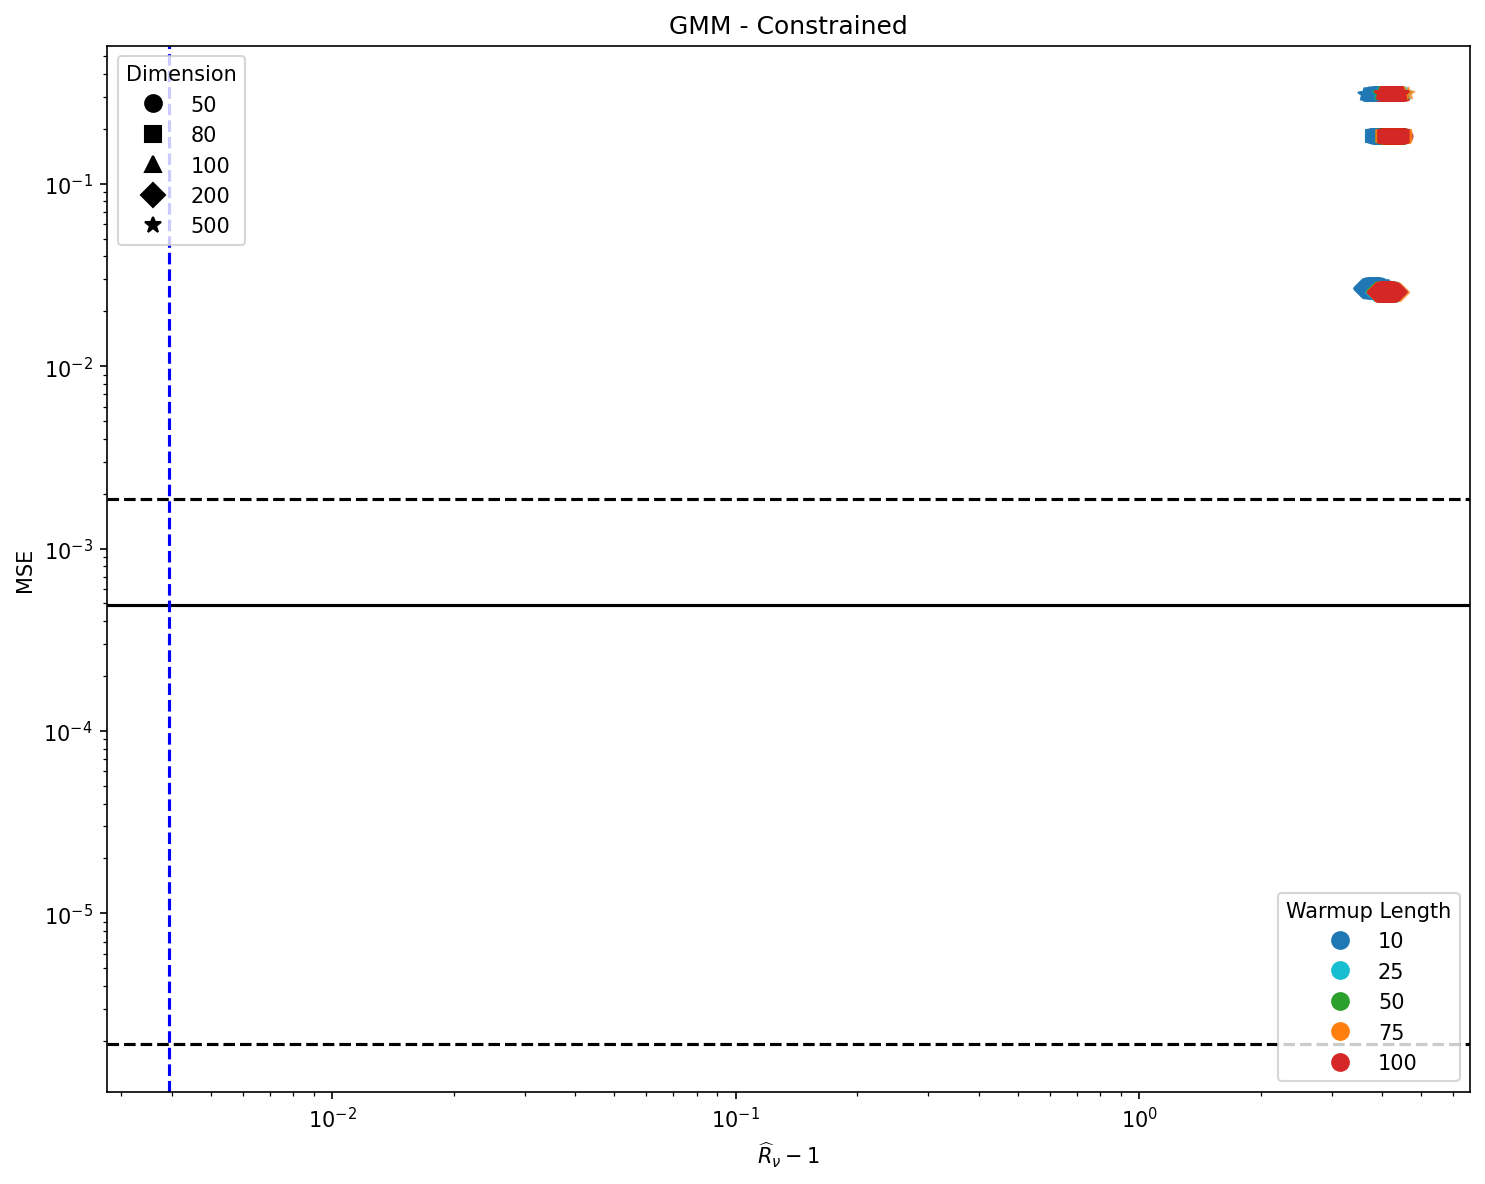

In [ ]:
MSE_vs_Rhat(GMM_R_hat_constrained_df, "GMM", naive=False)

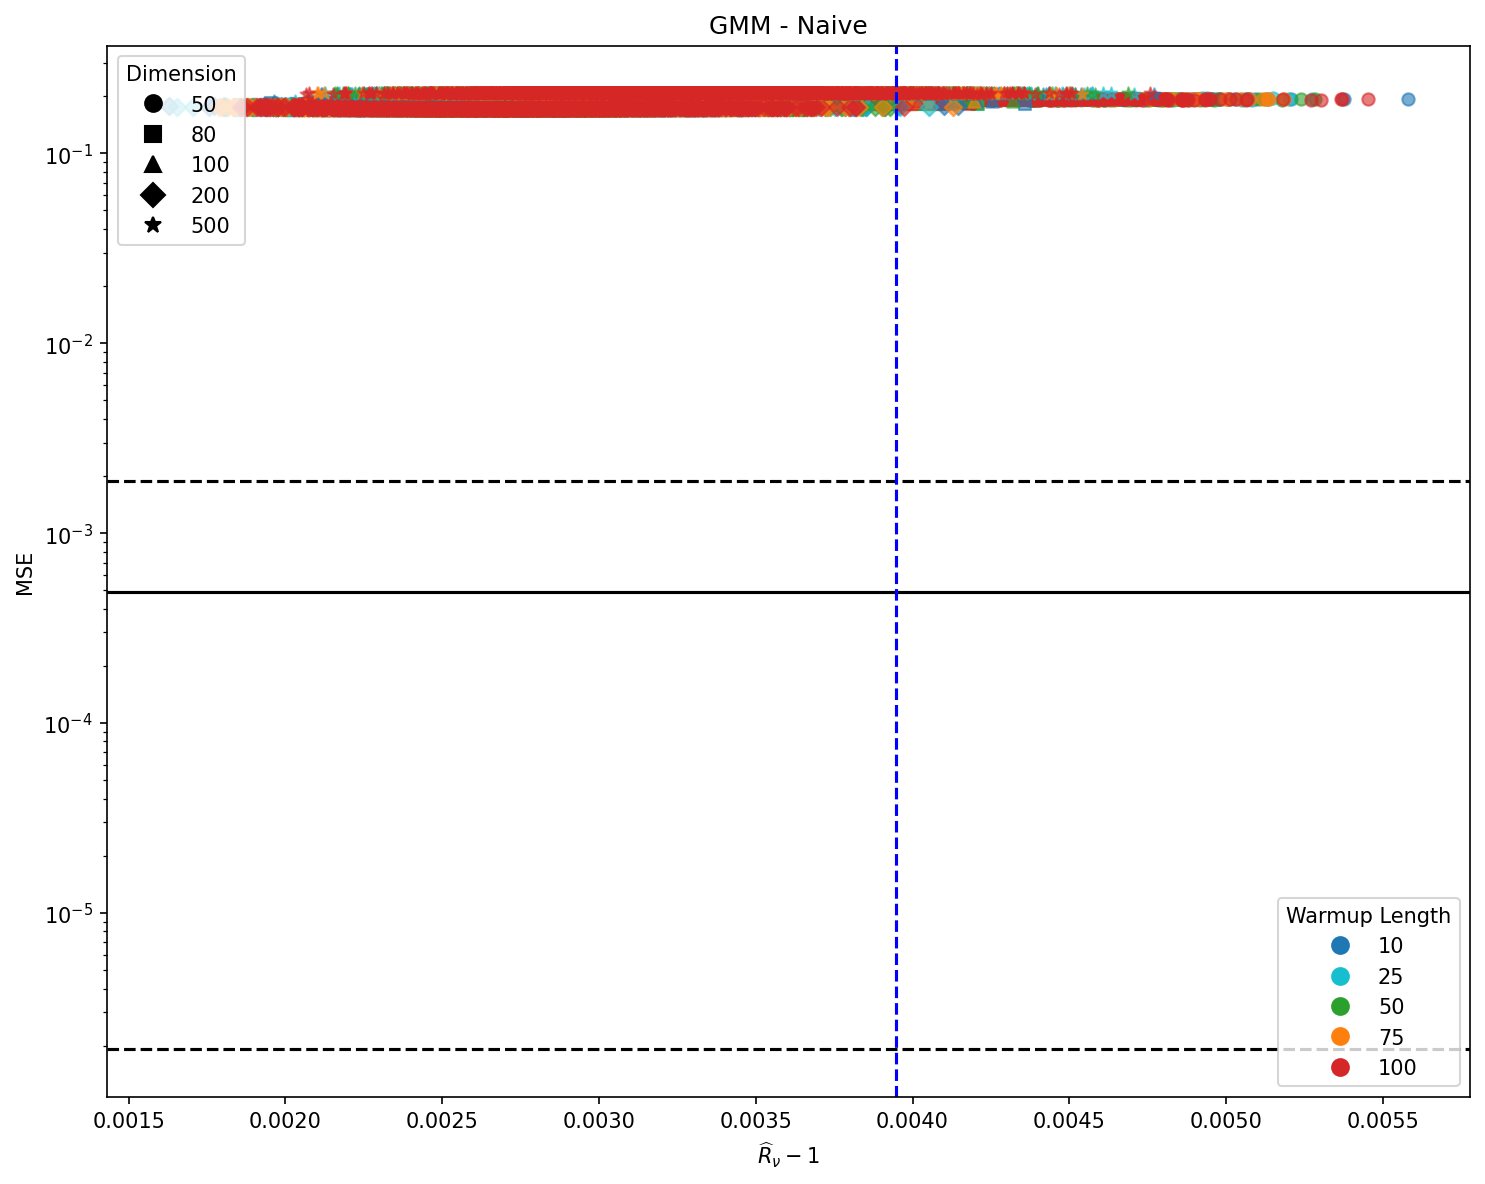

In [ ]:
MSE_vs_Rhat(GMM_R_hat_naive_df, "GMM", naive=True)

**MVN Part**

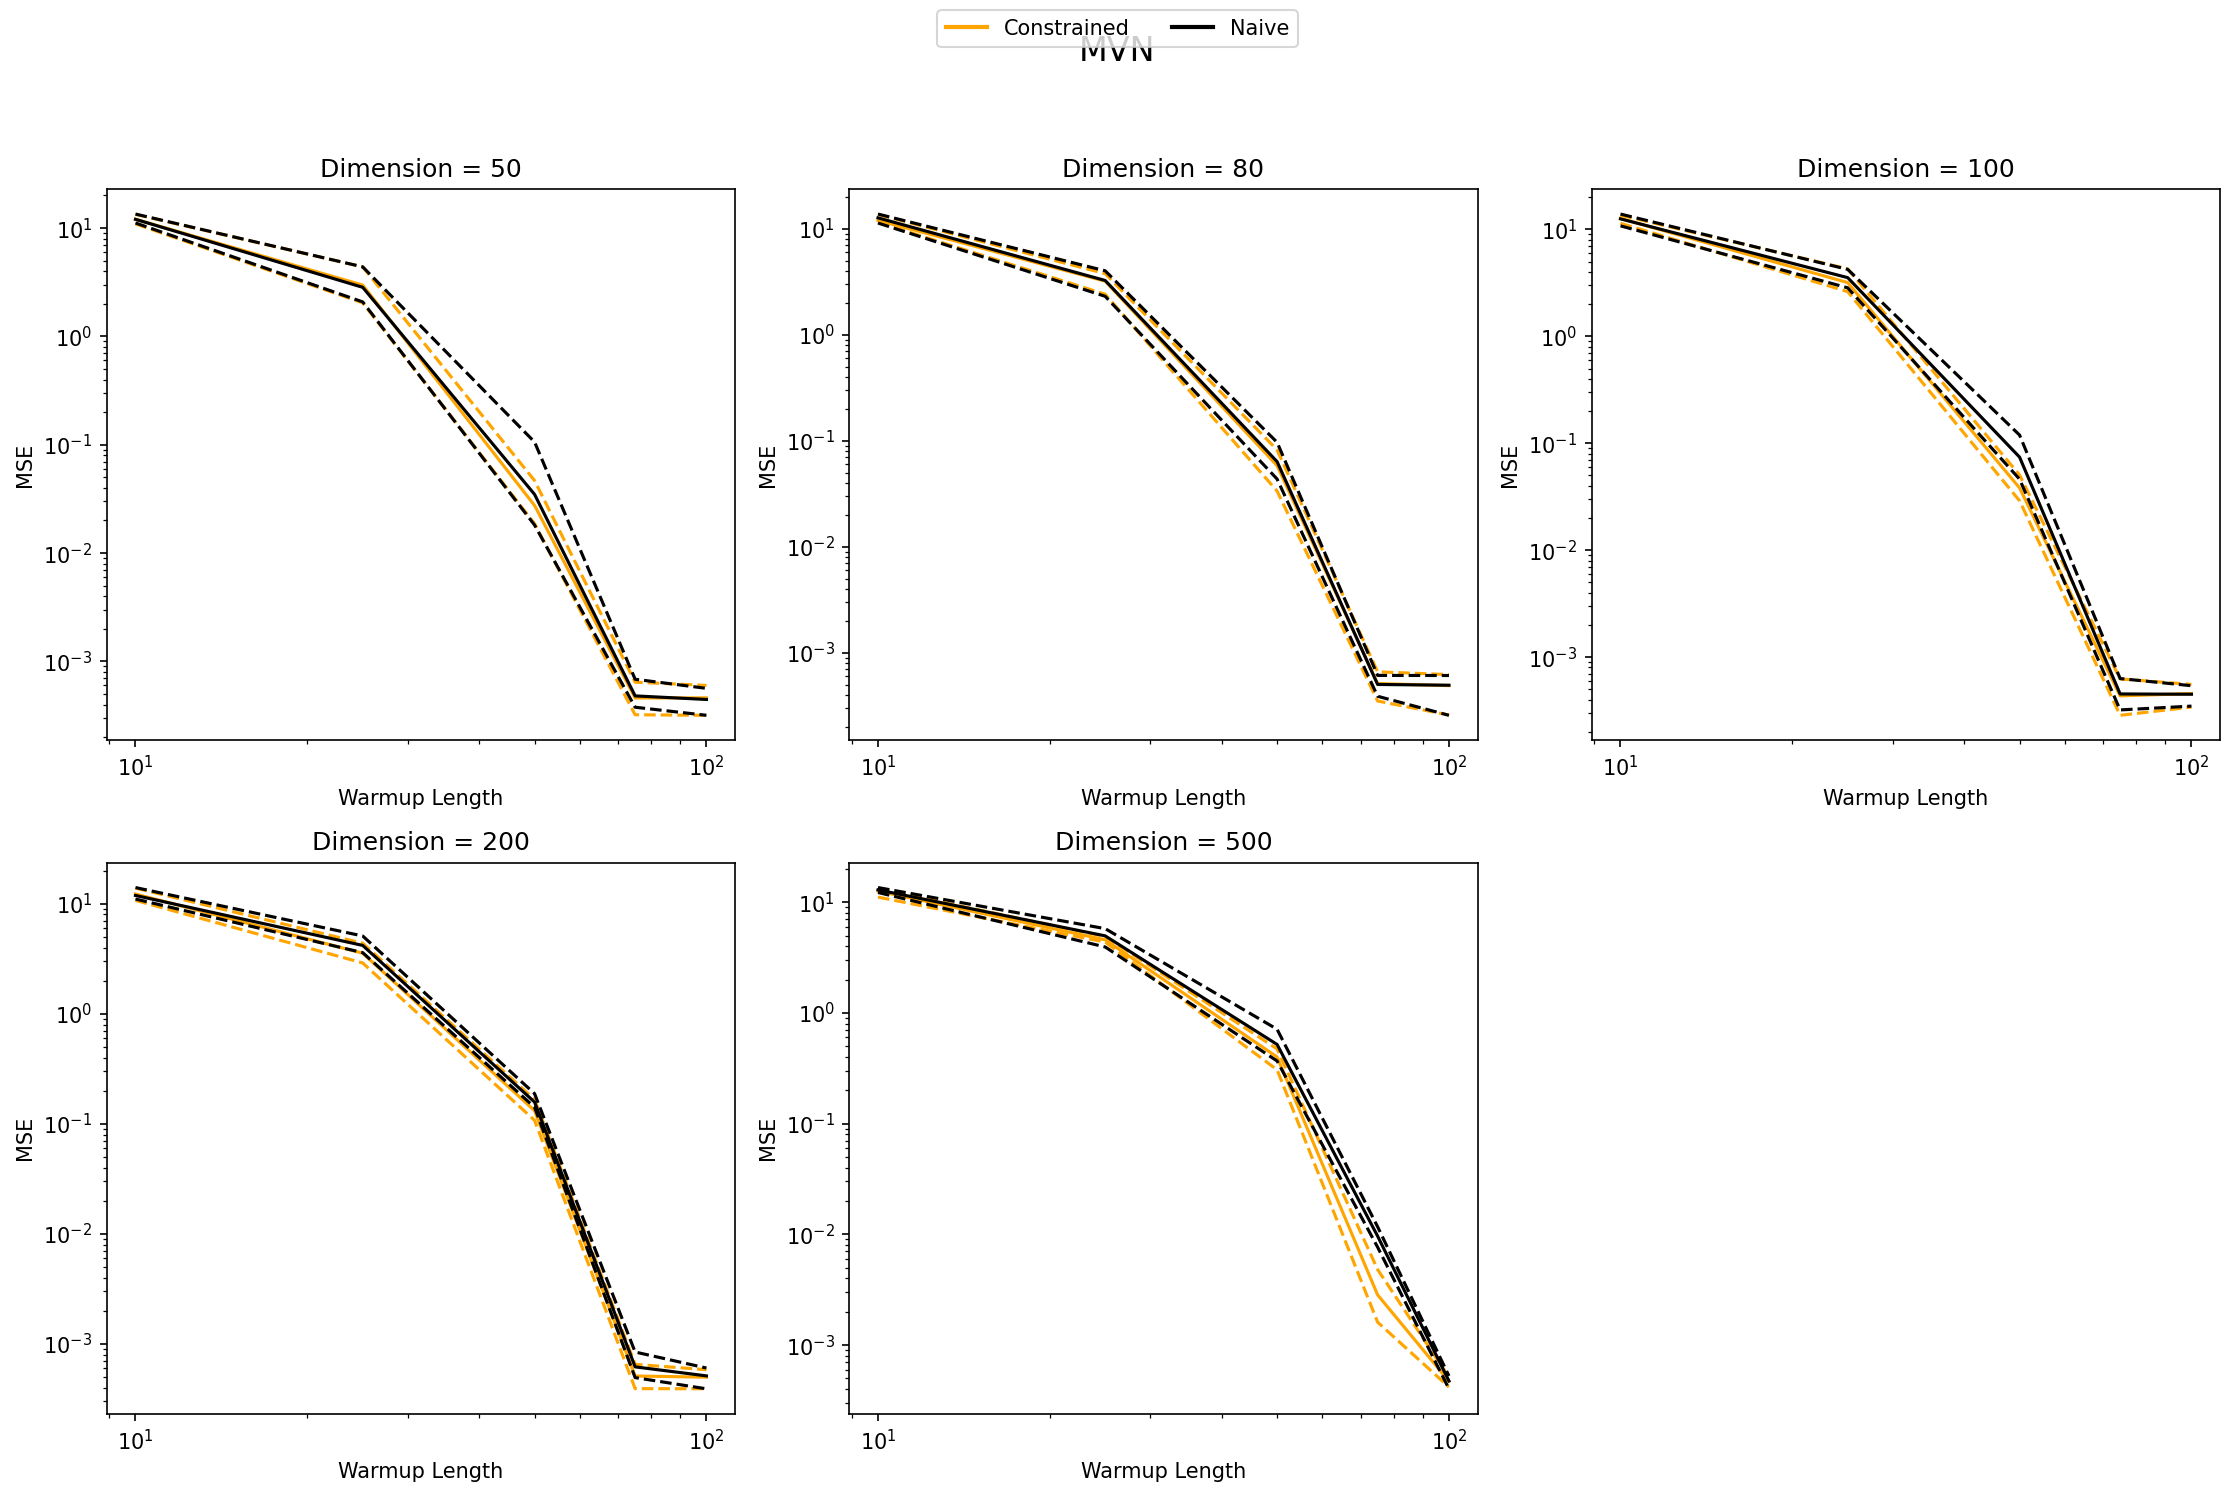

In [ ]:
MSE_line(MVN_MSE_constrained_df,MVN_MSE_naive_df,"MVN",'Warmup Length')

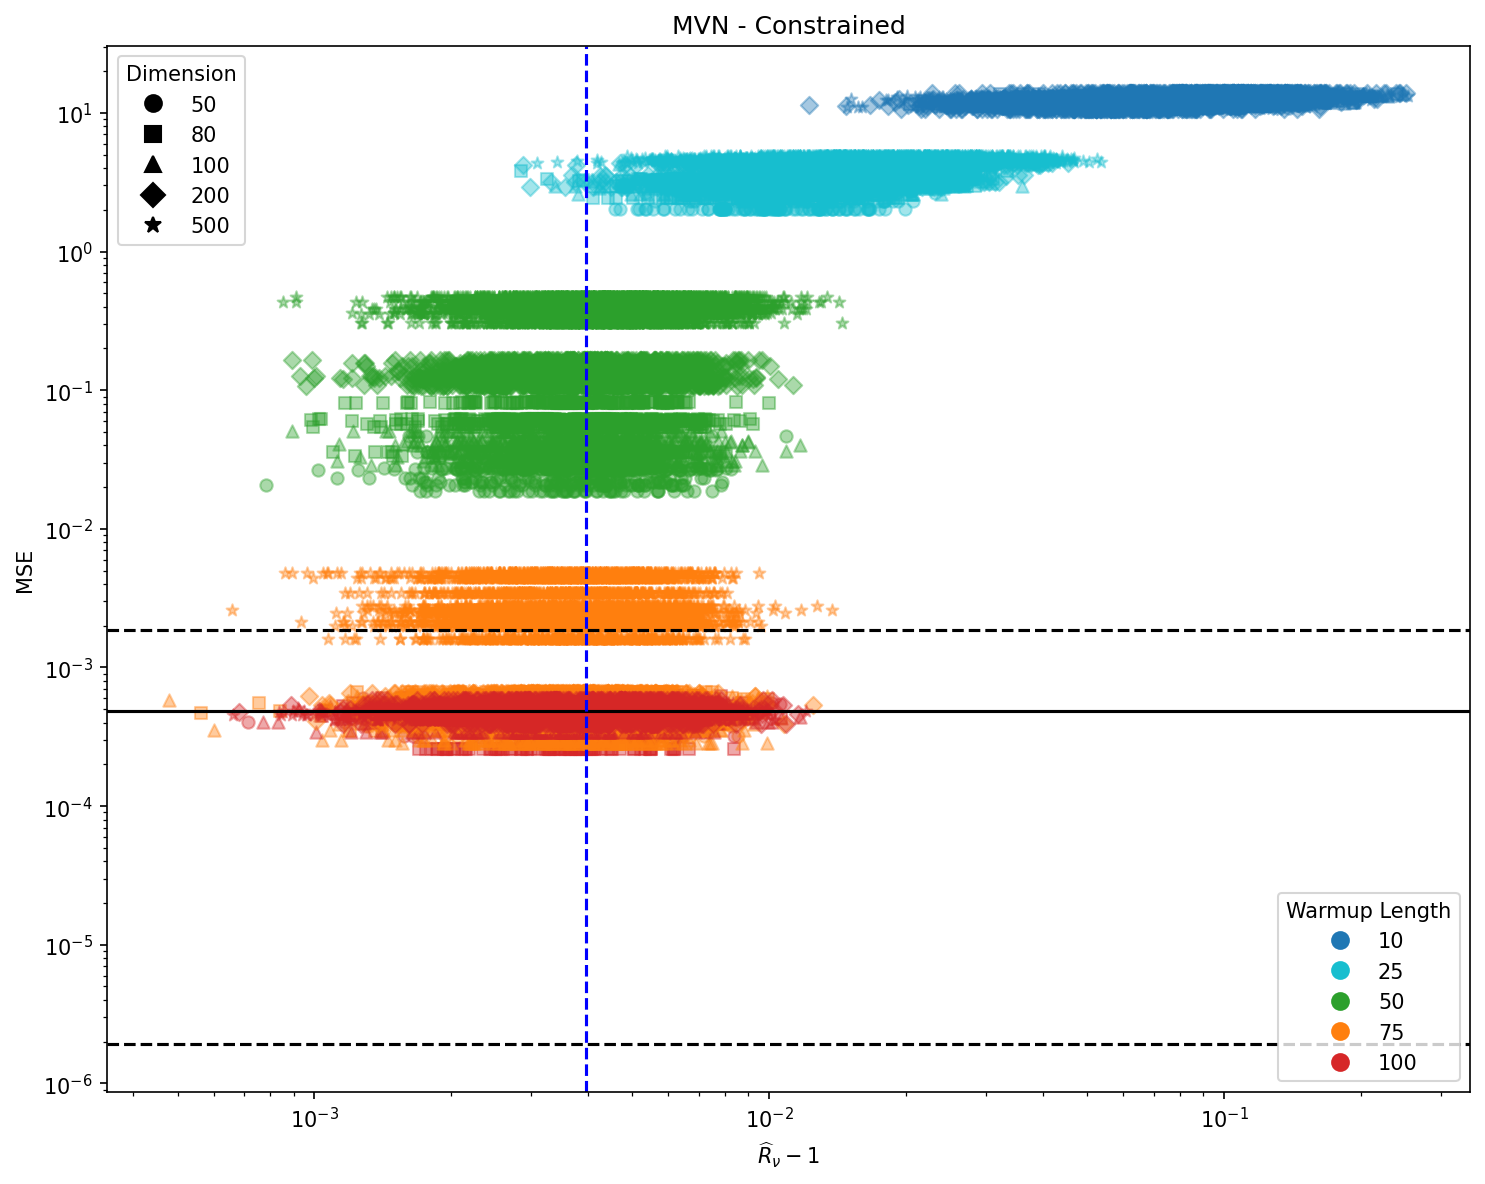

In [ ]:
MSE_vs_Rhat(MVN_R_hat_constrained_df, "MVN", naive=False)

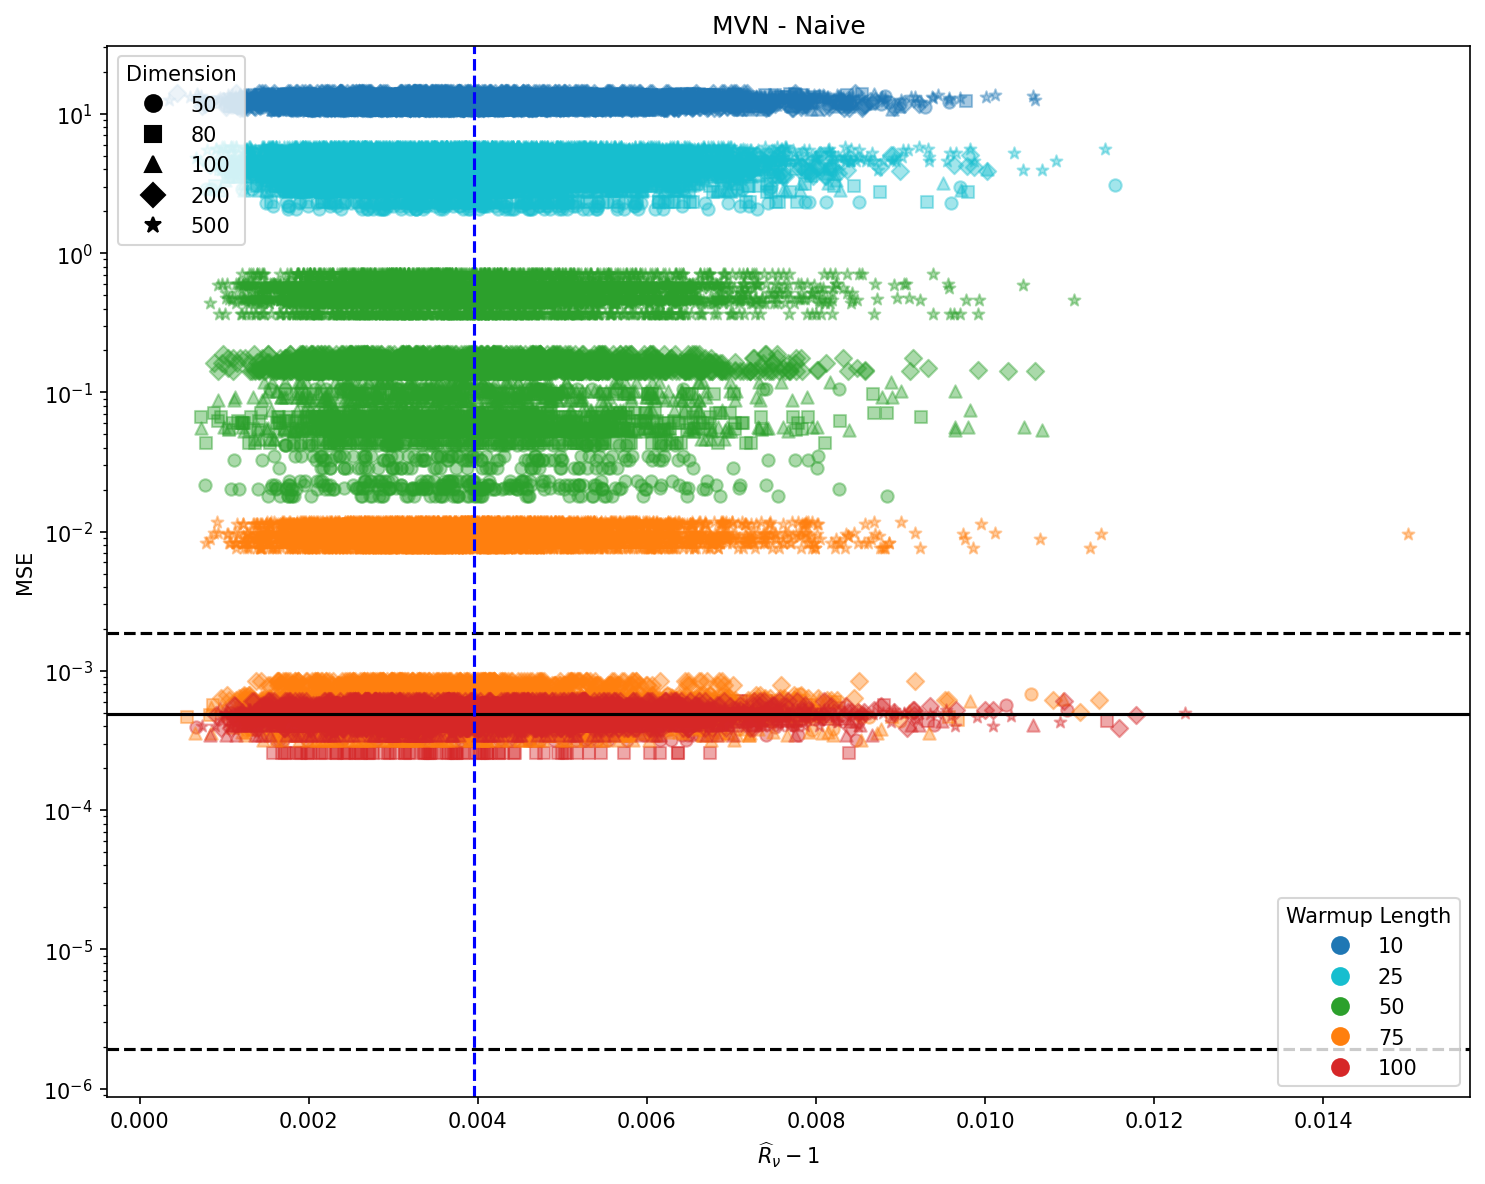

In [ ]:
MSE_vs_Rhat(MVN_R_hat_naive_df, "MVN", naive=True)